In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib

plt.style.use('sty.mplstyle')

atomic_mass_unit = 1.6605e-27 # kg
MAr = 39.95*atomic_mass_unit # Mass of argon in atomic mass units

def Interpolation(E1, E2, xsec1, xsec2, E):
    assert E1 < E2
    assert E >= E1
    assert E <= E2

    slope = (xsec2 - xsec1)/(E2-E1)
    interp = slope*(E-E1) + xsec1
    return interp

def MatchXSec(flux_energy, trid_energy, trid_xsec):
    xsec_matched = []

    for ii in range(len(flux_energy)):
        if flux_energy[ii] > trid_energy[-1]: # If the flux energy is larger than the maximum trident energy, set the matched xsec to 0.
            xsec_matched.append(0.0)
            continue
        elif flux_energy[ii] < trid_energy[0]: # If the flux energy range starts below the trident one, set the matched xsec to 0. Otherwise, these values will be skipped.
            xsec_matched.append(0.0)
            continue
        else:
            for jj in range(len(trid_energy)):
                if flux_energy[ii] == trid_energy[jj]: # In the unlikely event that the flux energy equals the trident energy, just output the cross section there.
                    xsec_matched.append(trid_xsec[jj])
                    continue
                if ((flux_energy[ii] > trid_energy[jj]) and (flux_energy[ii] < trid_energy[jj+1])): # Find the trident energy range for the flux energy. Interpolate there.
                    if (trid_xsec[jj] < 0) or (trid_xsec[jj+1] < 0): # Some xsec are negative in the 2tau proton case; ad hoc solution for now.
                        xsec_matched.append(0.0)
                    else:
                        xsec_interp = Interpolation(trid_energy[jj], trid_energy[jj+1], trid_xsec[jj], trid_xsec[jj+1], flux_energy[ii])
                        xsec_matched.append(xsec_interp)
    
    assert len(flux_energy) == len(xsec_matched)
    return xsec_matched

def ComputeNumberOfEvents(Flux, Energy_Flux, Trident_Energy, Trident_Xsec, POT=1, MD=1):
    # POT is in units of 10^{21}
    # MD is in units of tonnes
    Delta_Energy = Energy_Flux[1] - Energy_Flux[0]
    xsec_matched = MatchXSec(Energy_Flux, Trident_Energy, Trident_Xsec)
    number_of_events = (MD/MAr) * POT * Flux * xsec_matched * Delta_Energy
    number_of_events = number_of_events*1e-19
    return number_of_events

# Upload Cross Sections for different Form Factors

In [2]:
####################################################################################################################
########################### Cross Sections for the process: vmu -> ve e+ mu- #######################################
####################################################################################################################
Energy_ve_e_mu_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/3pF/vmu_to_ve_e+_mu-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=0) # GeV
Xsec_ve_e_mu_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/3pF/vmu_to_ve_e+_mu-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=1) # fb

Energy_ve_e_mu_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/Helm/vmu_to_ve_e+_mu-_coh_Ar_[H]_xsec', delimiter=',', usecols=0) # GeV
Xsec_ve_e_mu_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/Helm/vmu_to_ve_e+_mu-_coh_Ar_[H]_xsec', delimiter=',', usecols=1) # fb

Energy_ve_e_mu_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/KN/vmu_to_ve_e+_mu-_coh_Ar_[KN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_ve_e_mu_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/KN/vmu_to_ve_e+_mu-_coh_Ar_[KN]_xsec', delimiter=',', usecols=1) # fb

Energy_ve_e_mu_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/adKN/vmu_to_ve_e+_mu-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_ve_e_mu_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_ve_e+_mu-_xsec/Coherent/Argon/adKN/vmu_to_ve_e+_mu-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=1) # fb

####################################################################################################################
########################### Cross Sections for the process: vmu -> vmu e+ e- #######################################
####################################################################################################################
Energy_vmu_e_e_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/3pF/vmu_to_vmu_e+_e-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_e_e_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/3pF/vmu_to_vmu_e+_e-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_e_e_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/Helm/vmu_to_vmu_e+_e-_coh_Ar_[H]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_e_e_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/Helm/vmu_to_vmu_e+_e-_coh_Ar_[H]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_e_e_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/KN/vmu_to_vmu_e+_e-_coh_Ar_[KN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_e_e_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/KN/vmu_to_vmu_e+_e-_coh_Ar_[KN]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_e_e_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/adKN/vmu_to_vmu_e+_e-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_e_e_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_e+_e-_xsec/Coherent/Argon/adKN/vmu_to_vmu_e+_e-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=1) # fb

####################################################################################################################
########################### Cross Sections for the process: vmu -> vmu mu+ mu- #####################################
####################################################################################################################
Energy_vmu_mu_mu_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/3pF/vmu_to_vmu_mu+_mu-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_mu_mu_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/3pF/vmu_to_vmu_mu+_mu-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_mu_mu_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/Helm/vmu_to_vmu_mu+_mu-_coh_Ar_[H]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_mu_mu_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/Helm/vmu_to_vmu_mu+_mu-_coh_Ar_[H]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_mu_mu_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/KN/vmu_to_vmu_mu+_mu-_coh_Ar_[KN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_mu_mu_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/KN/vmu_to_vmu_mu+_mu-_coh_Ar_[KN]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_mu_mu_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/adKN/vmu_to_vmu_mu+_mu-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_mu_mu_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_mu+_mu-_xsec/Coherent/Argon/adKN/vmu_to_vmu_mu+_mu-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=1) # fb

####################################################################################################################
########################### Cross Sections for the process: vmu -> vmu tau+ tau- ###################################
####################################################################################################################
Energy_vmu_tau_tau_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/3pF/vmu_to_vmu_tau+_tau-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_tau_tau_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/3pF/vmu_to_vmu_tau+_tau-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_tau_tau_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/Helm/vmu_to_vmu_tau+_tau-_coh_Ar_[H]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_tau_tau_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/Helm/vmu_to_vmu_tau+_tau-_coh_Ar_[H]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_tau_tau_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/KN/vmu_to_vmu_tau+_tau-_coh_Ar_[KN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_tau_tau_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/KN/vmu_to_vmu_tau+_tau-_coh_Ar_[KN]_xsec', delimiter=',', usecols=1) # fb

Energy_vmu_tau_tau_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/adKN/vmu_to_vmu_tau+_tau-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vmu_tau_tau_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vmu_tau+_tau-_xsec/Coherent/Argon/adKN/vmu_to_vmu_tau+_tau-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=1) # fb

####################################################################################################################
########################### Cross Sections for the process: vmu -> vtau tau+ mu- ###################################
####################################################################################################################
Energy_vtau_tau_mu_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/3pF/vmu_to_vtau_tau+_mu-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vtau_tau_mu_coh_Ar_3pF = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/3pF/vmu_to_vtau_tau+_mu-_coh_Ar_[3pF]_xsec', delimiter=',', usecols=1) # fb

Energy_vtau_tau_mu_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/Helm/vmu_to_vtau_tau+_mu-_coh_Ar_[H]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vtau_tau_mu_coh_Ar_Helm = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/Helm/vmu_to_vtau_tau+_mu-_coh_Ar_[H]_xsec', delimiter=',', usecols=1) # fb

Energy_vtau_tau_mu_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/KN/vmu_to_vtau_tau+_mu-_coh_Ar_[KN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vtau_tau_mu_coh_Ar_KN = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/KN/vmu_to_vtau_tau+_mu-_coh_Ar_[KN]_xsec', delimiter=',', usecols=1) # fb

Energy_vtau_tau_mu_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/adKN/vmu_to_vtau_tau+_mu-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=0) # GeV
Xsec_vtau_tau_mu_coh_Ar_adKN = np.loadtxt('../csv/CrossSections/vmu_to_vtau_tau+_mu-_xsec/Coherent/Argon/adKN/vmu_to_vtau_tau+_mu-_coh_Ar_[adKN]_xsec', delimiter=',', usecols=1) # fb

# Event Distribution at MiniBooNE (Neutrino Flux - Neutrino Mode)

In [3]:
####################################################################################################################
################################ Flux at MiniBooNE Neutrino Mode ###################################################
####################################################################################################################
Elow_MiniBooNE_NuMode = np.loadtxt('../csv/Fluxes/MiniBooNE_Fluxes_NuMode.dat.txt', usecols=0) # GeV
Ehigh_MiniBooNE_NuMode = np.loadtxt('../csv/Fluxes/MiniBooNE_Fluxes_NuMode.dat.txt', usecols=1) # GeV
Flux_MiniBooNE_NuMode = 2e5*np.loadtxt('../csv/Fluxes/MiniBooNE_Fluxes_NuMode.dat.txt', usecols=2) # numu/m^2/POT/GeV
Enu_MiniBooNE_NuMode = (Elow_MiniBooNE_NuMode + Ehigh_MiniBooNE_NuMode)/2

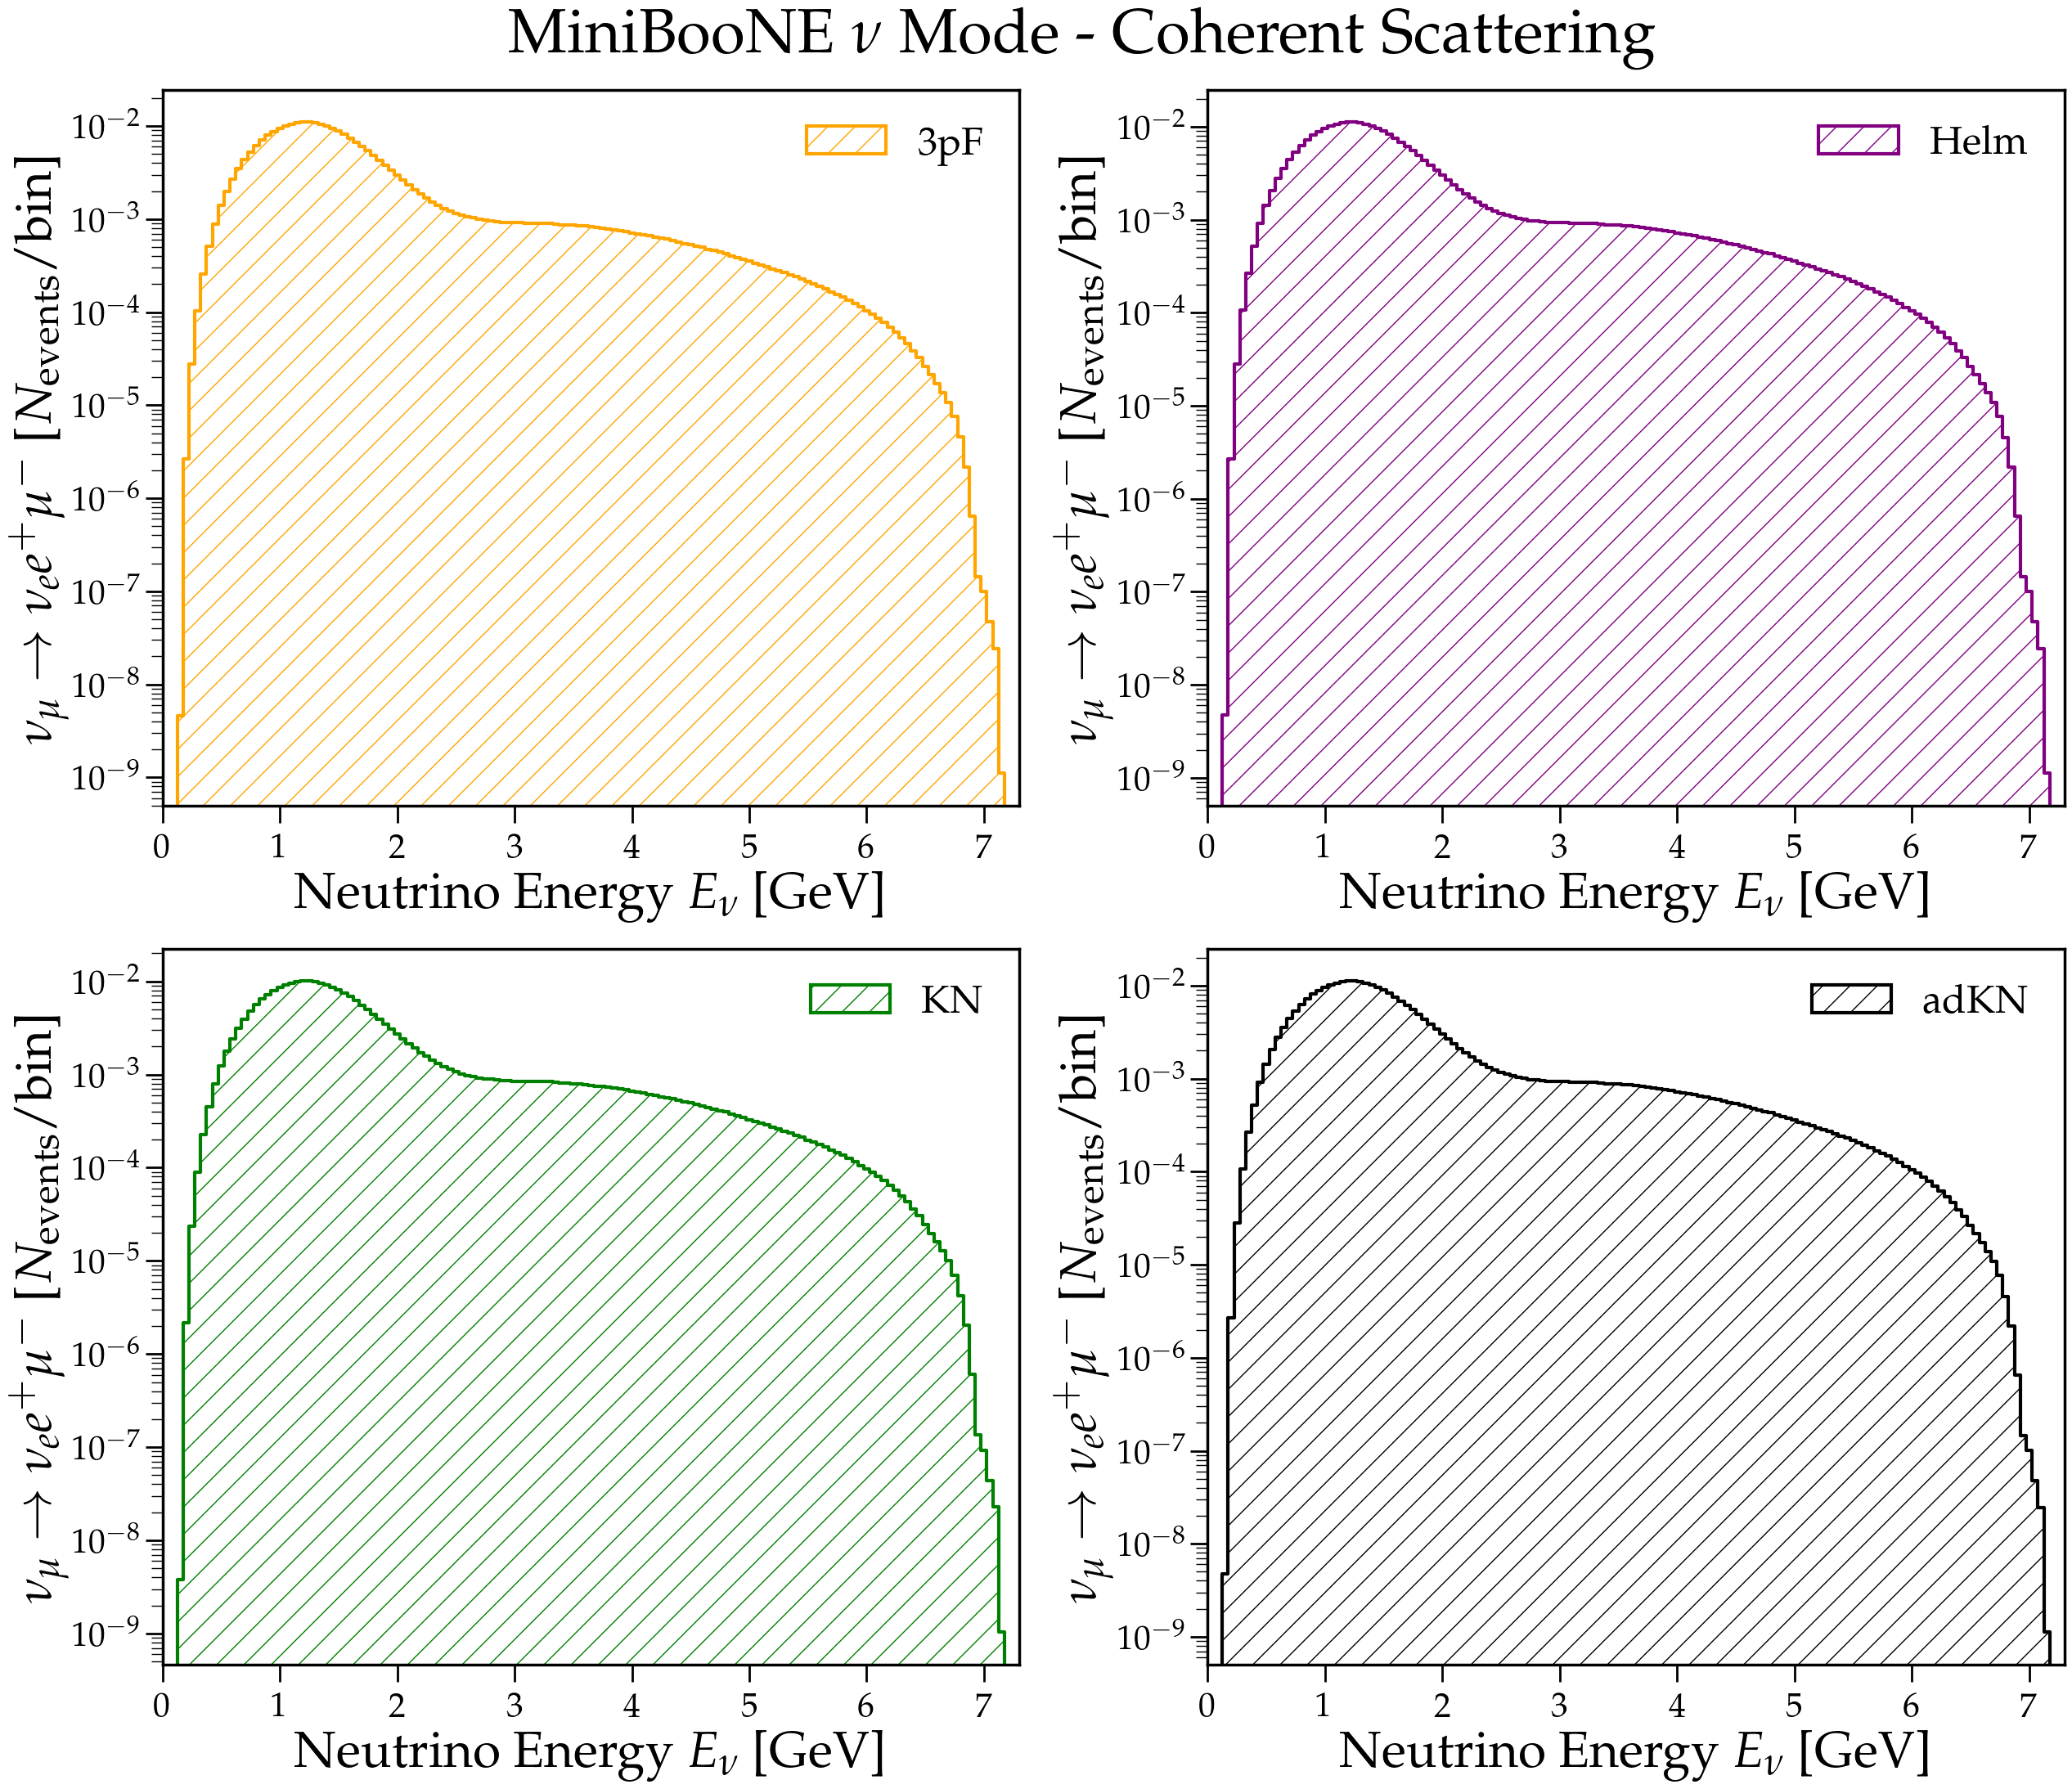

In [4]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> ve e+ mu- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_ve_e_mu_coh_Ar_3pF, Xsec_ve_e_mu_coh_Ar_3pF, POT=0.66, MD=112)
Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_ve_e_mu_coh_Ar_Helm, Xsec_ve_e_mu_coh_Ar_Helm, POT=0.66, MD=112)
Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_ve_e_mu_coh_Ar_KN, Xsec_ve_e_mu_coh_Ar_KN, POT=0.66, MD=112)
Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_ve_e_mu_coh_Ar_adKN, Xsec_ve_e_mu_coh_Ar_adKN, POT=0.66, MD=112)

ax1.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_ve_e_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,7.3])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_e e^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'MiniBooNE $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/MiniBooNE_events_per_bin_ve_e+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/MiniBooNE_events_per_bin_ve_e+_mu-.png', bbox_inches='tight', transparent=False)

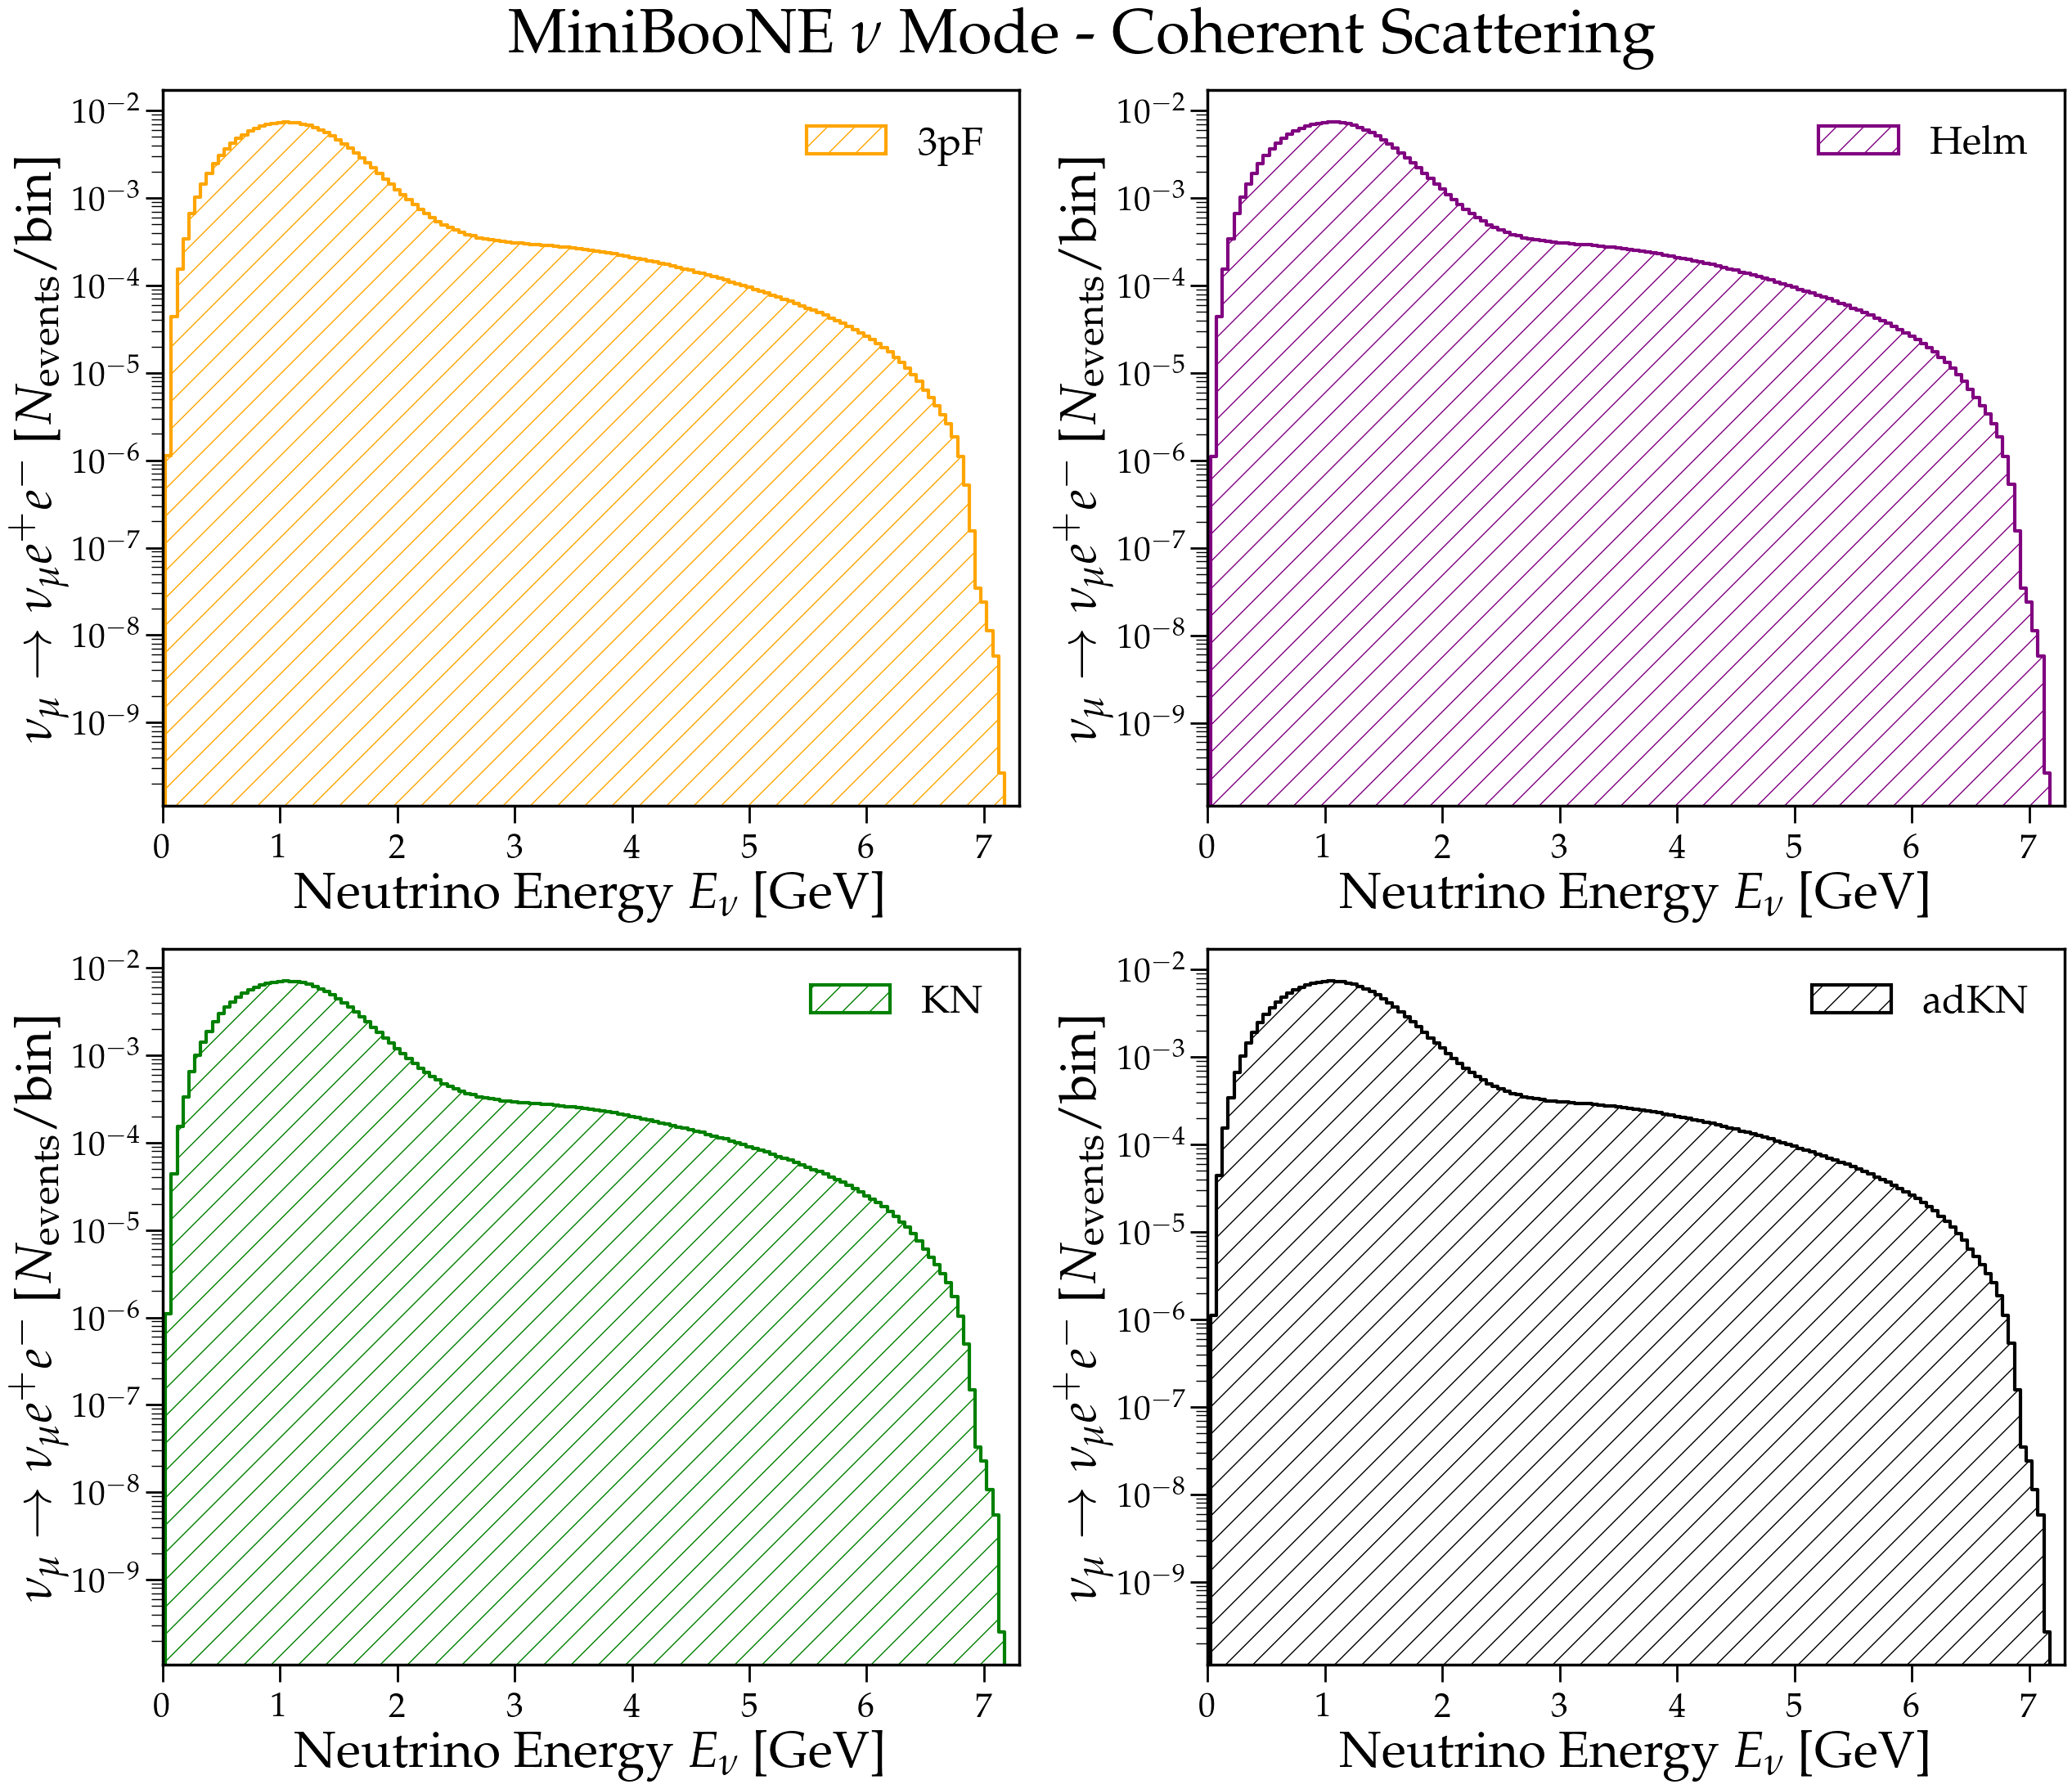

In [5]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vmu e+ e- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_3pF = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_e_e_coh_Ar_3pF, Xsec_vmu_e_e_coh_Ar_3pF, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_Helm = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_e_e_coh_Ar_Helm, Xsec_vmu_e_e_coh_Ar_Helm, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_KN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_e_e_coh_Ar_KN, Xsec_vmu_e_e_coh_Ar_KN, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_adKN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_e_e_coh_Ar_adKN, Xsec_vmu_e_e_coh_Ar_adKN, POT=0.66, MD=112)

ax1.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_e_e_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,7.3])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu e^{+} e^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'MiniBooNE $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/MiniBooNE_events_per_bin_vmu_e+_e-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/MiniBooNE_events_per_bin_vmu_e+_e-.png', bbox_inches='tight', transparent=False)

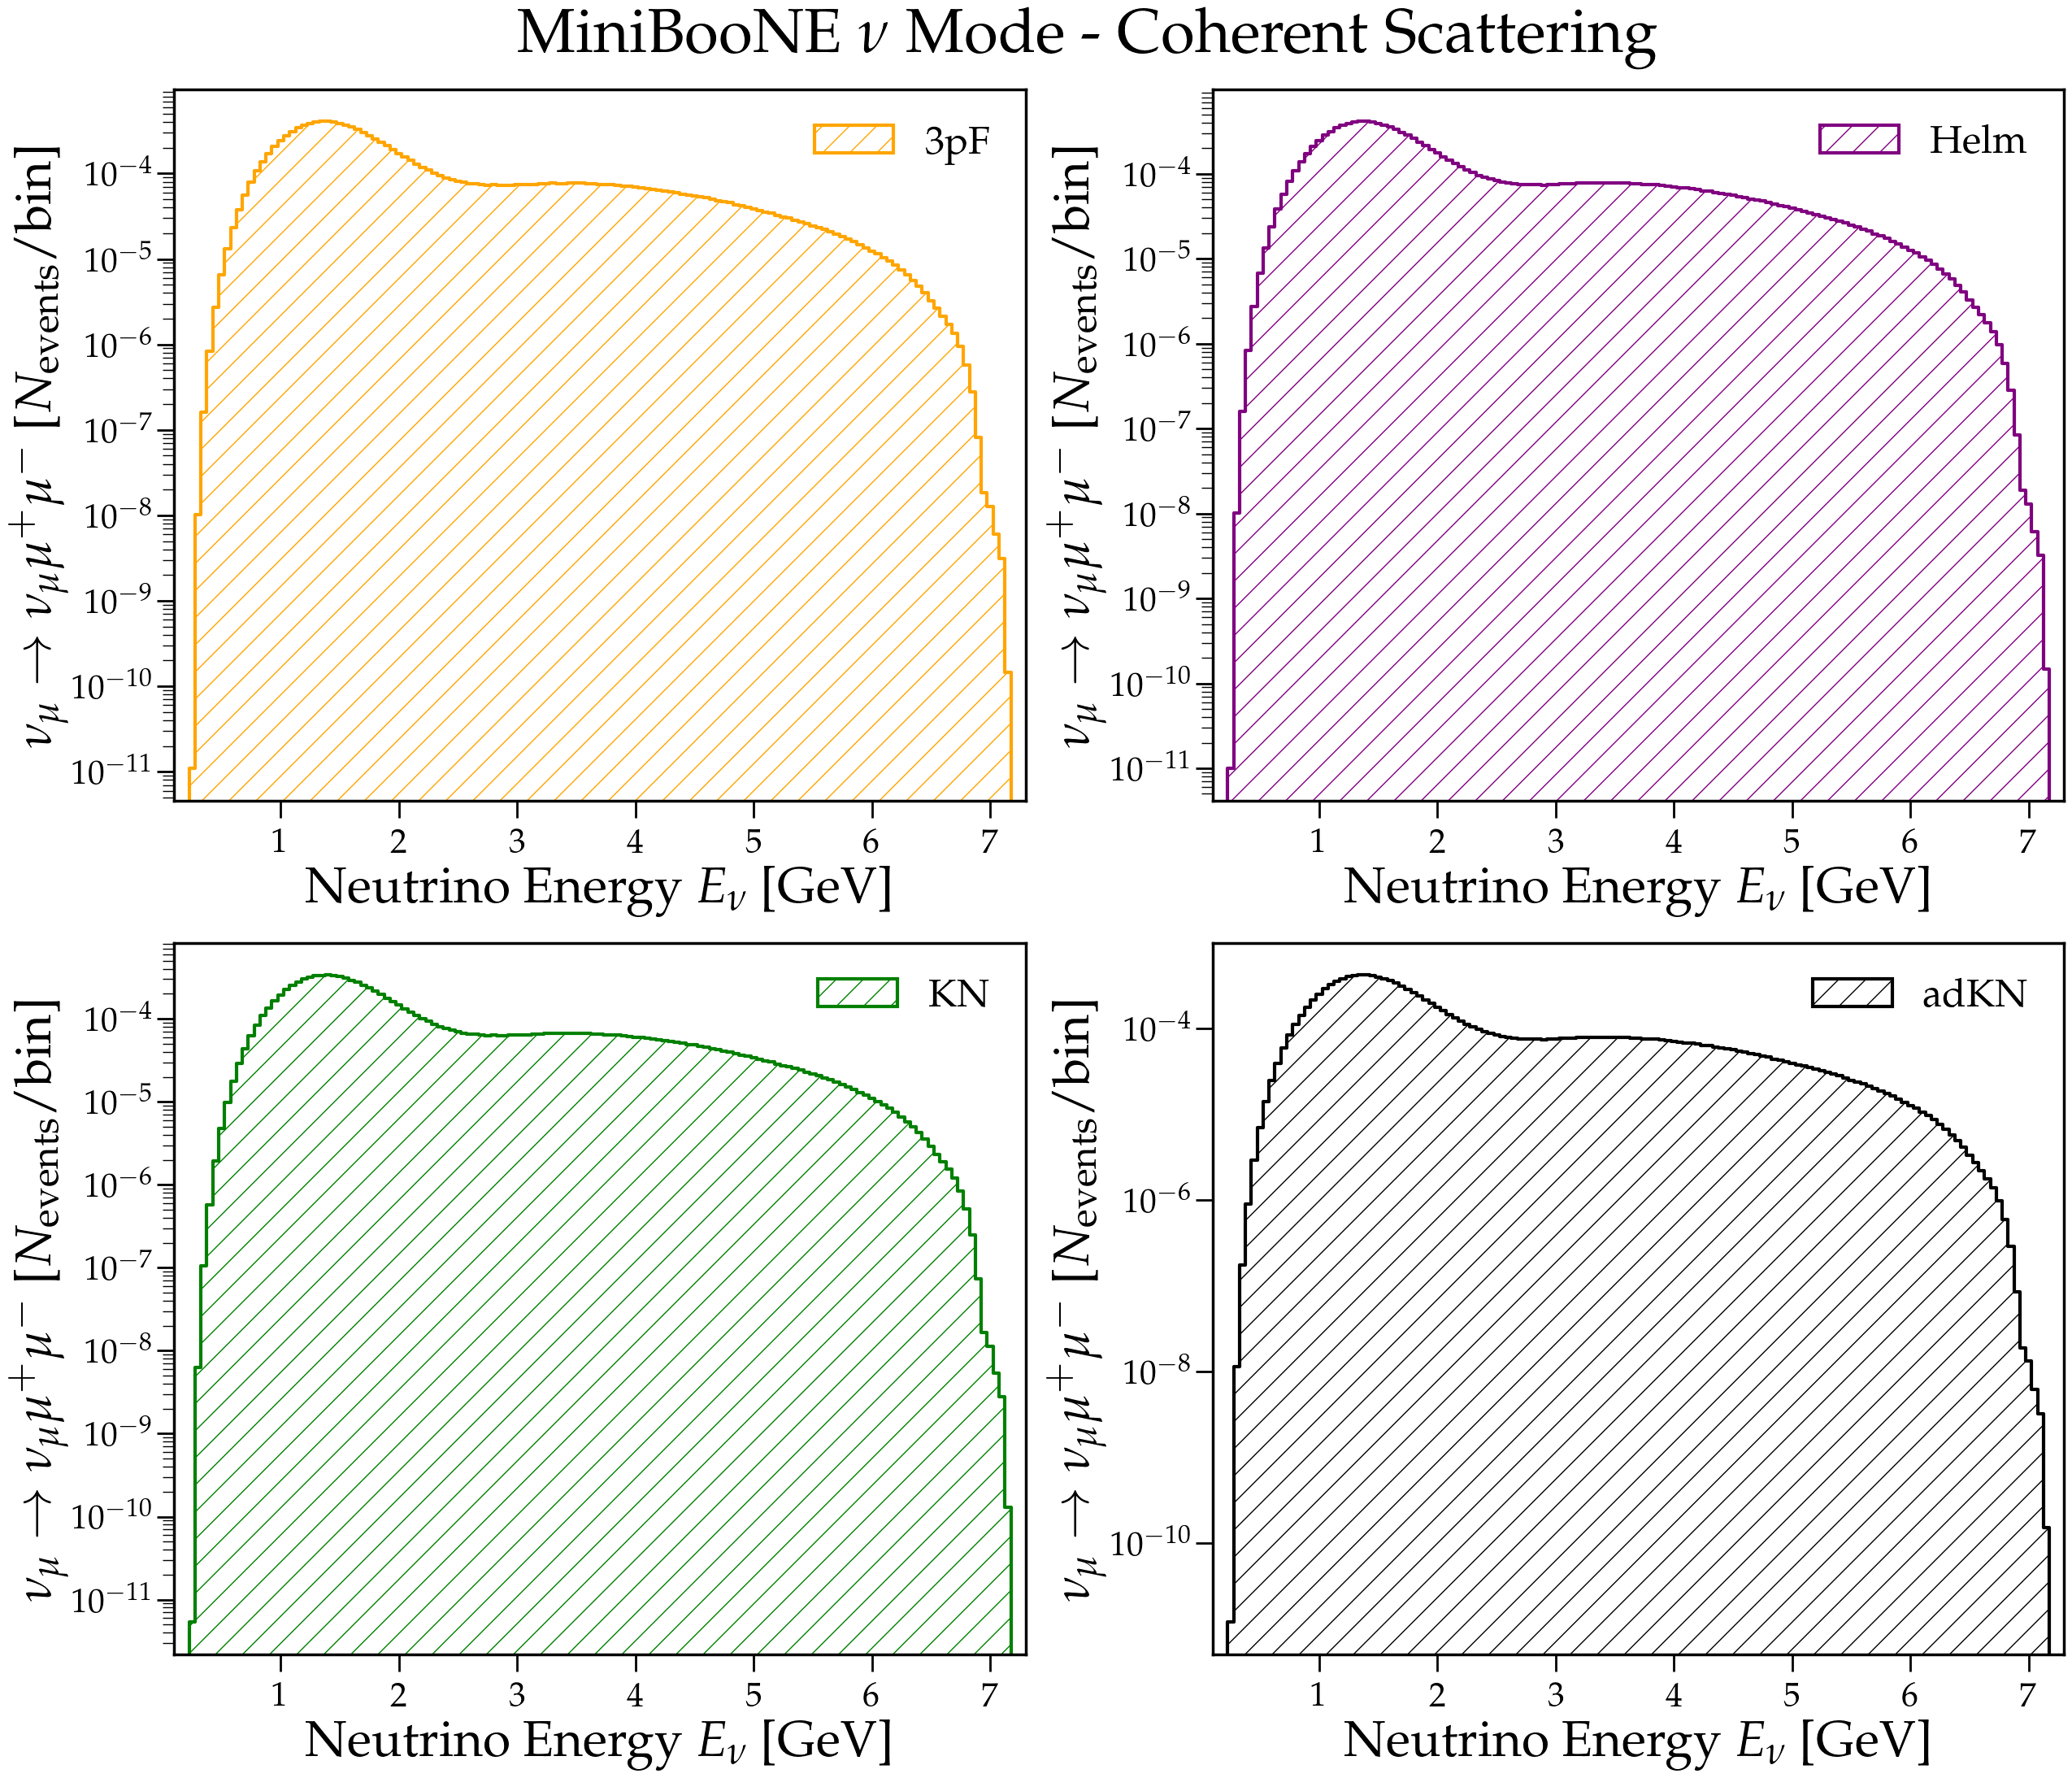

In [6]:
####################################################################################################################
########################### Cross Sections for the process: vmu -> vmu mu+ mu- #####################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_mu_mu_coh_Ar_3pF, Xsec_vmu_mu_mu_coh_Ar_3pF, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_mu_mu_coh_Ar_Helm, Xsec_vmu_mu_mu_coh_Ar_Helm, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_mu_mu_coh_Ar_KN, Xsec_vmu_mu_mu_coh_Ar_KN, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_mu_mu_coh_Ar_adKN, Xsec_vmu_mu_mu_coh_Ar_adKN, POT=0.66, MD=112)

ax1.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_mu_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0.1,7.3])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'MiniBooNE $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/MiniBooNE_events_per_bin_vmu_mu+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/MiniBooNE_events_per_bin_vmu_mu+_mu-.png', bbox_inches='tight', transparent=False)

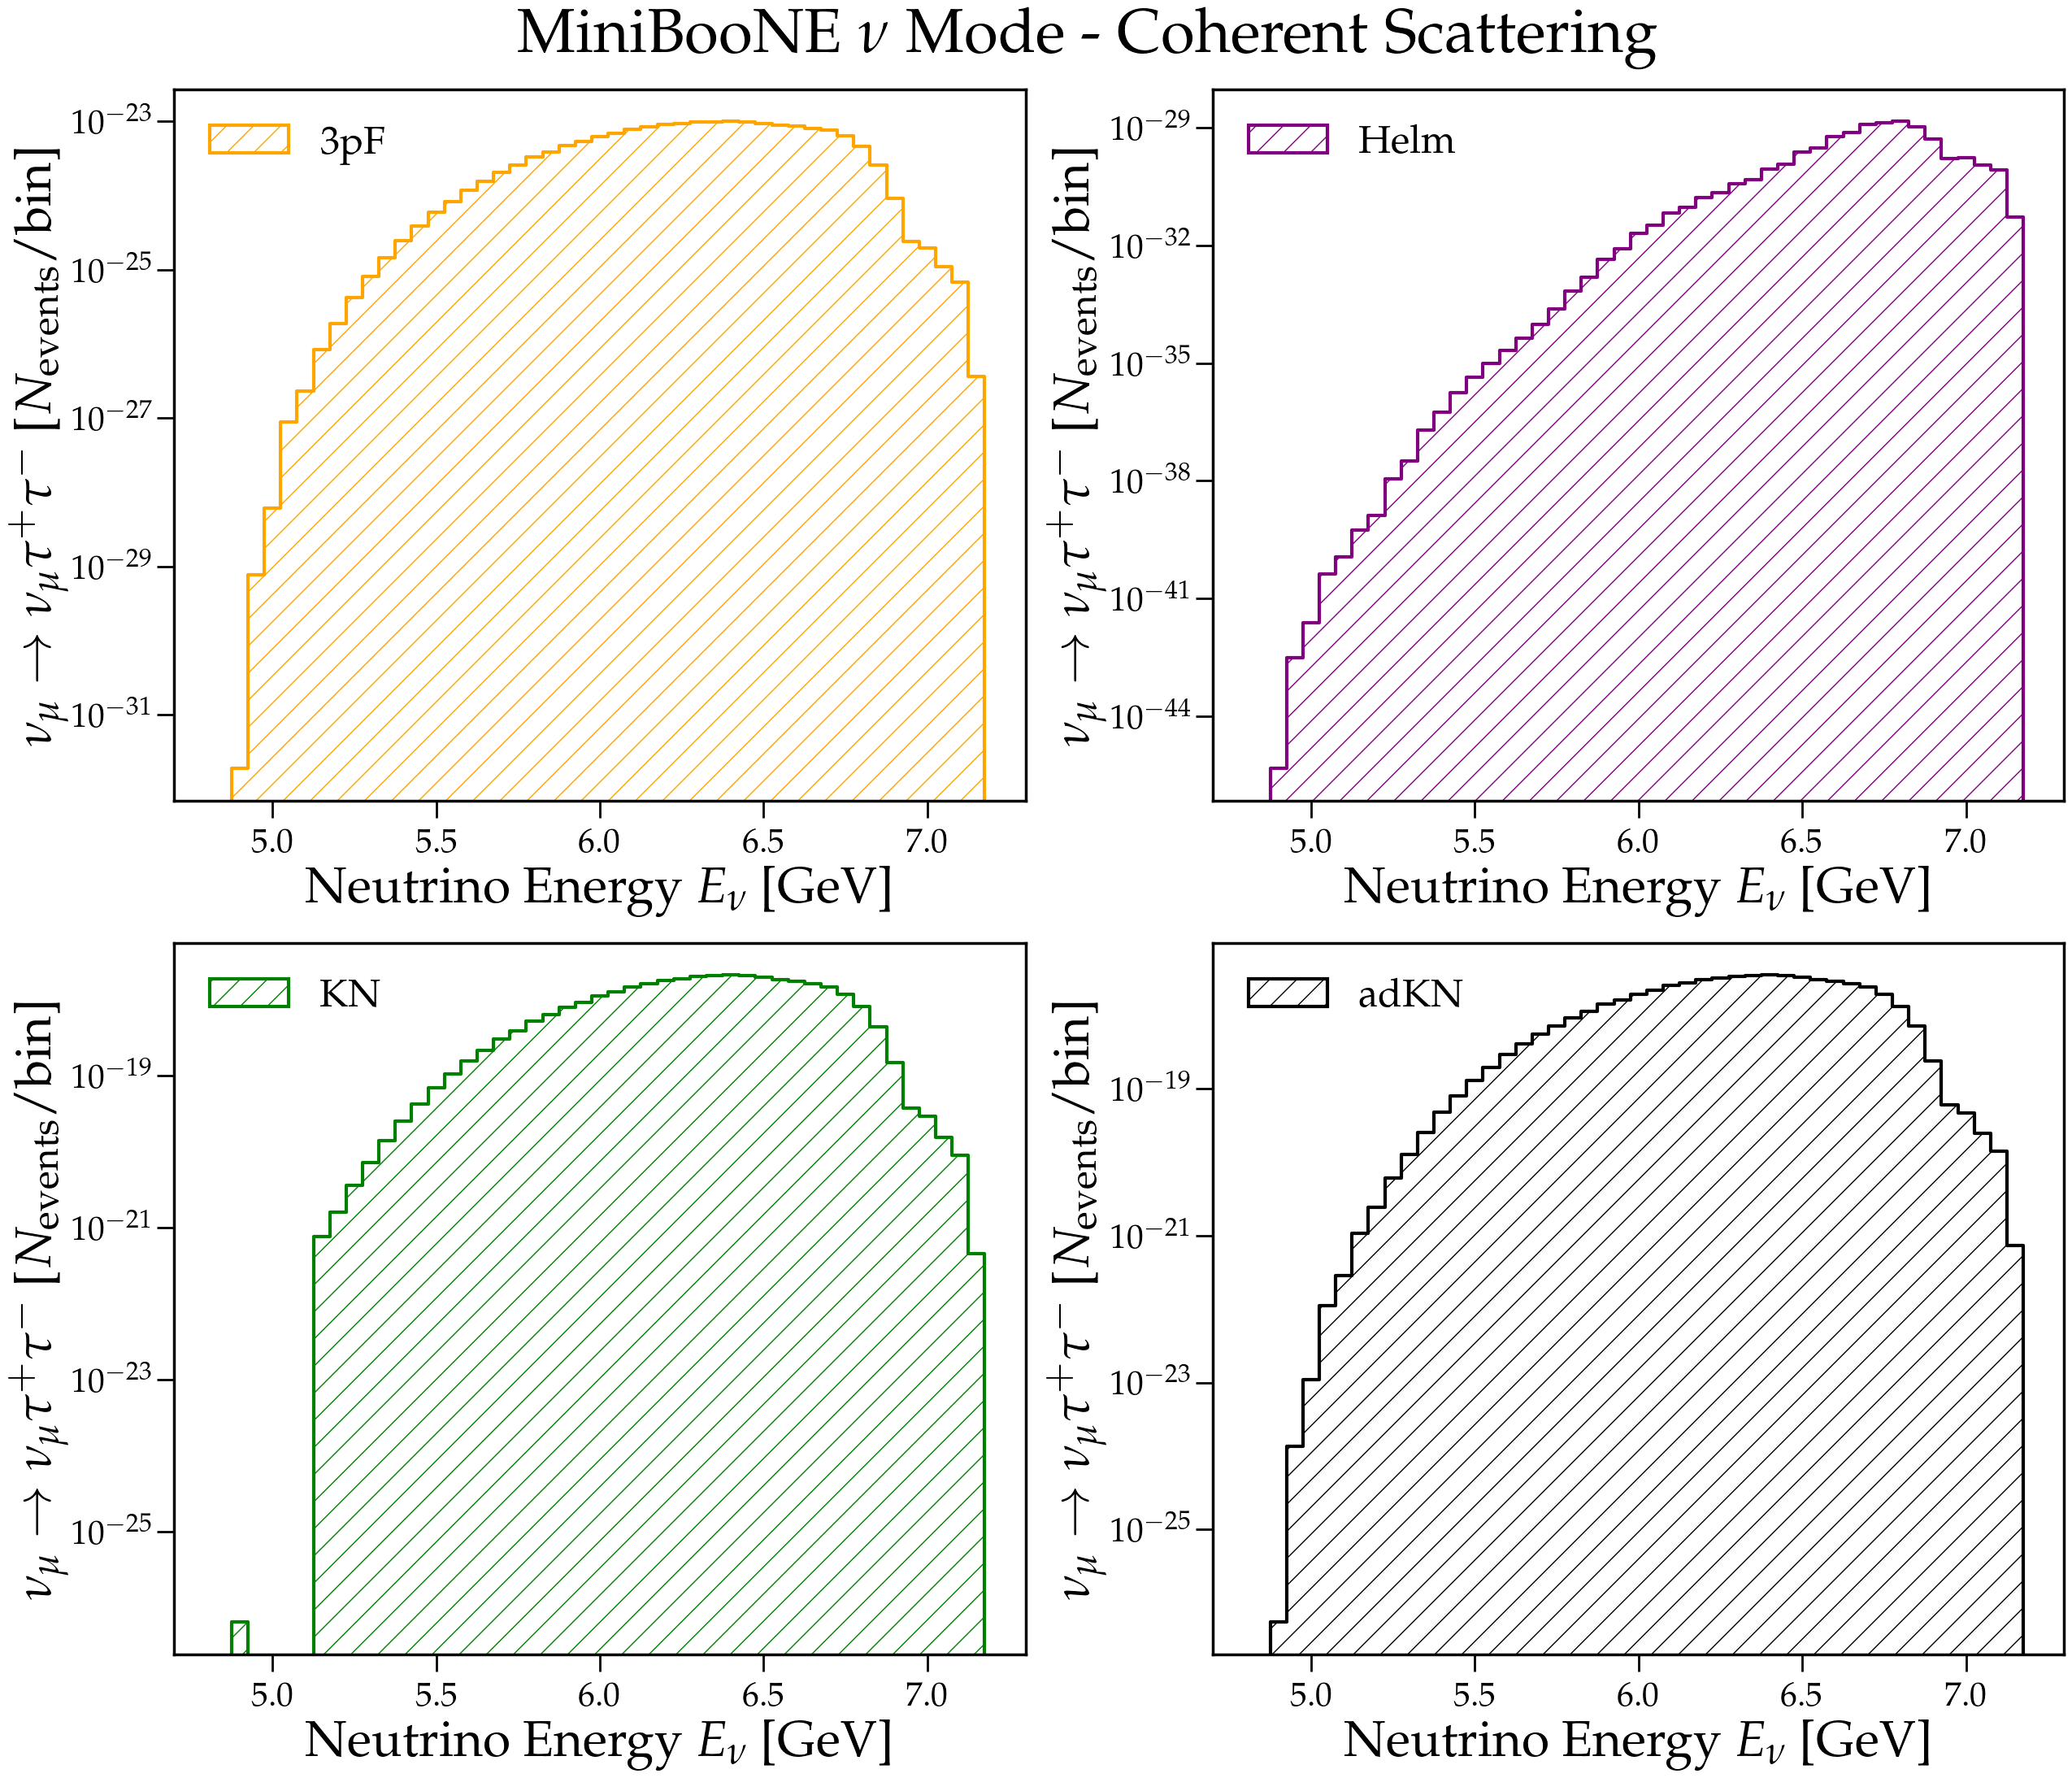

In [7]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vmu tau+ tau- ###################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_3pF = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_tau_tau_coh_Ar_3pF, Xsec_vmu_tau_tau_coh_Ar_3pF, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_Helm = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_tau_tau_coh_Ar_Helm, Xsec_vmu_tau_tau_coh_Ar_Helm, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_KN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_tau_tau_coh_Ar_KN, Xsec_vmu_tau_tau_coh_Ar_KN, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_adKN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vmu_tau_tau_coh_Ar_adKN, Xsec_vmu_tau_tau_coh_Ar_adKN, POT=0.66, MD=112)

ax1.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vmu_tau_tau_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([4.7,7.3])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'MiniBooNE $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/MiniBooNE_events_per_bin_vmu_tau+_tau-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/MiniBooNE_events_per_bin_vmu_tau+_tau-.png', bbox_inches='tight', transparent=False)

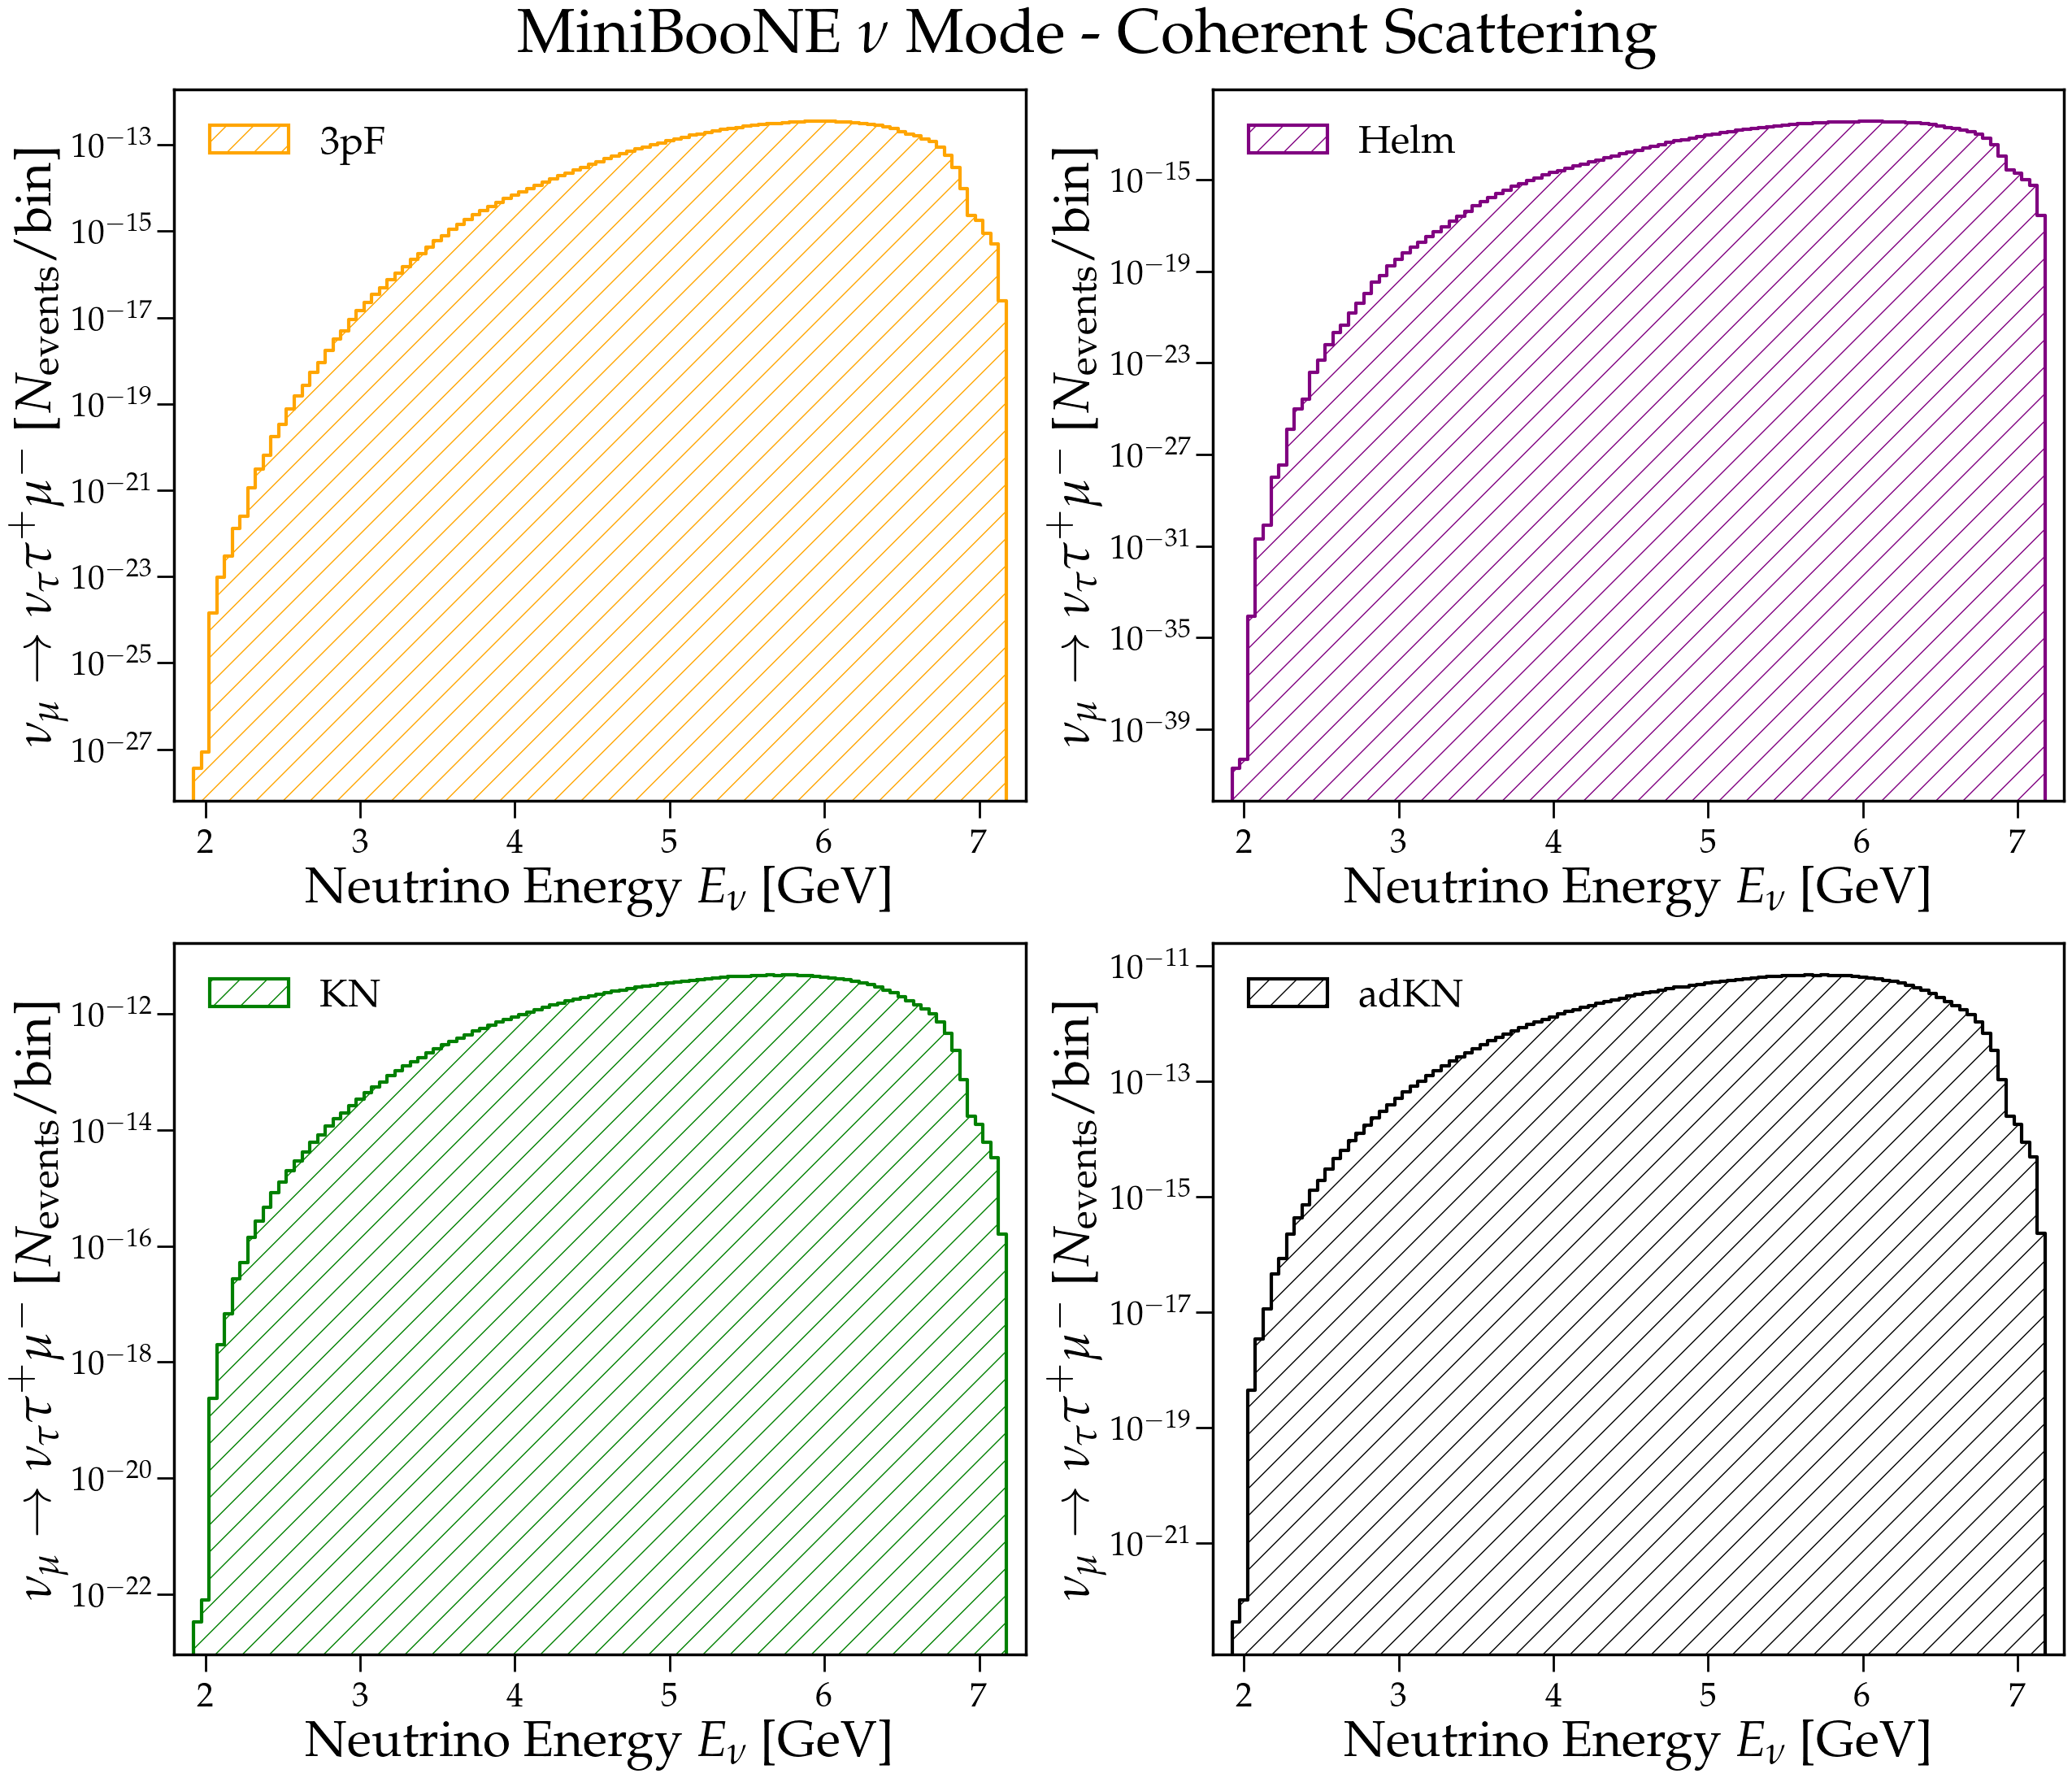

In [8]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vtau tau+ mu- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vtau_tau_mu_coh_Ar_3pF, Xsec_vtau_tau_mu_coh_Ar_3pF, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vtau_tau_mu_coh_Ar_Helm, Xsec_vtau_tau_mu_coh_Ar_Helm, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vtau_tau_mu_coh_Ar_KN, Xsec_vtau_tau_mu_coh_Ar_KN, POT=0.66, MD=112)
Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_MiniBooNE_NuMode, Enu_MiniBooNE_NuMode, Energy_vtau_tau_mu_coh_Ar_adKN, Xsec_vtau_tau_mu_coh_Ar_adKN, POT=0.66, MD=112)

ax1.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_MiniBooNE_NuMode, Events_MiniBooNE_Numode_vtau_tau_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([1.8,7.3])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'MiniBooNE $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/MiniBooNE_events_per_bin_vtau_tau+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/MiniBooNE_events_per_bin_vtau_tau+_mu-.png', bbox_inches='tight', transparent=False)

# Event Distribution at SBND (Neutrino Flux - Neutrino Mode)

In [9]:
####################################################################################################################
################################ Flux at SBND Neutrino Mode ###################################################
####################################################################################################################
Elow_SBND_NuMode = np.loadtxt('../csv/Fluxes/SBND_Fluxes_NeutrinoMode.dat', usecols=0) # GeV
Ehigh_SBND_NuMode = np.loadtxt('../csv/Fluxes/SBND_Fluxes_NeutrinoMode.dat', usecols=1) # GeV
Flux_SBND_NuMode = 2e-5*np.loadtxt('../csv/Fluxes/SBND_Fluxes_NeutrinoMode.dat', usecols=2) # numu/m^2/POT/GeV
Enu_SBND_NuMode = (Elow_SBND_NuMode + Ehigh_SBND_NuMode)/2

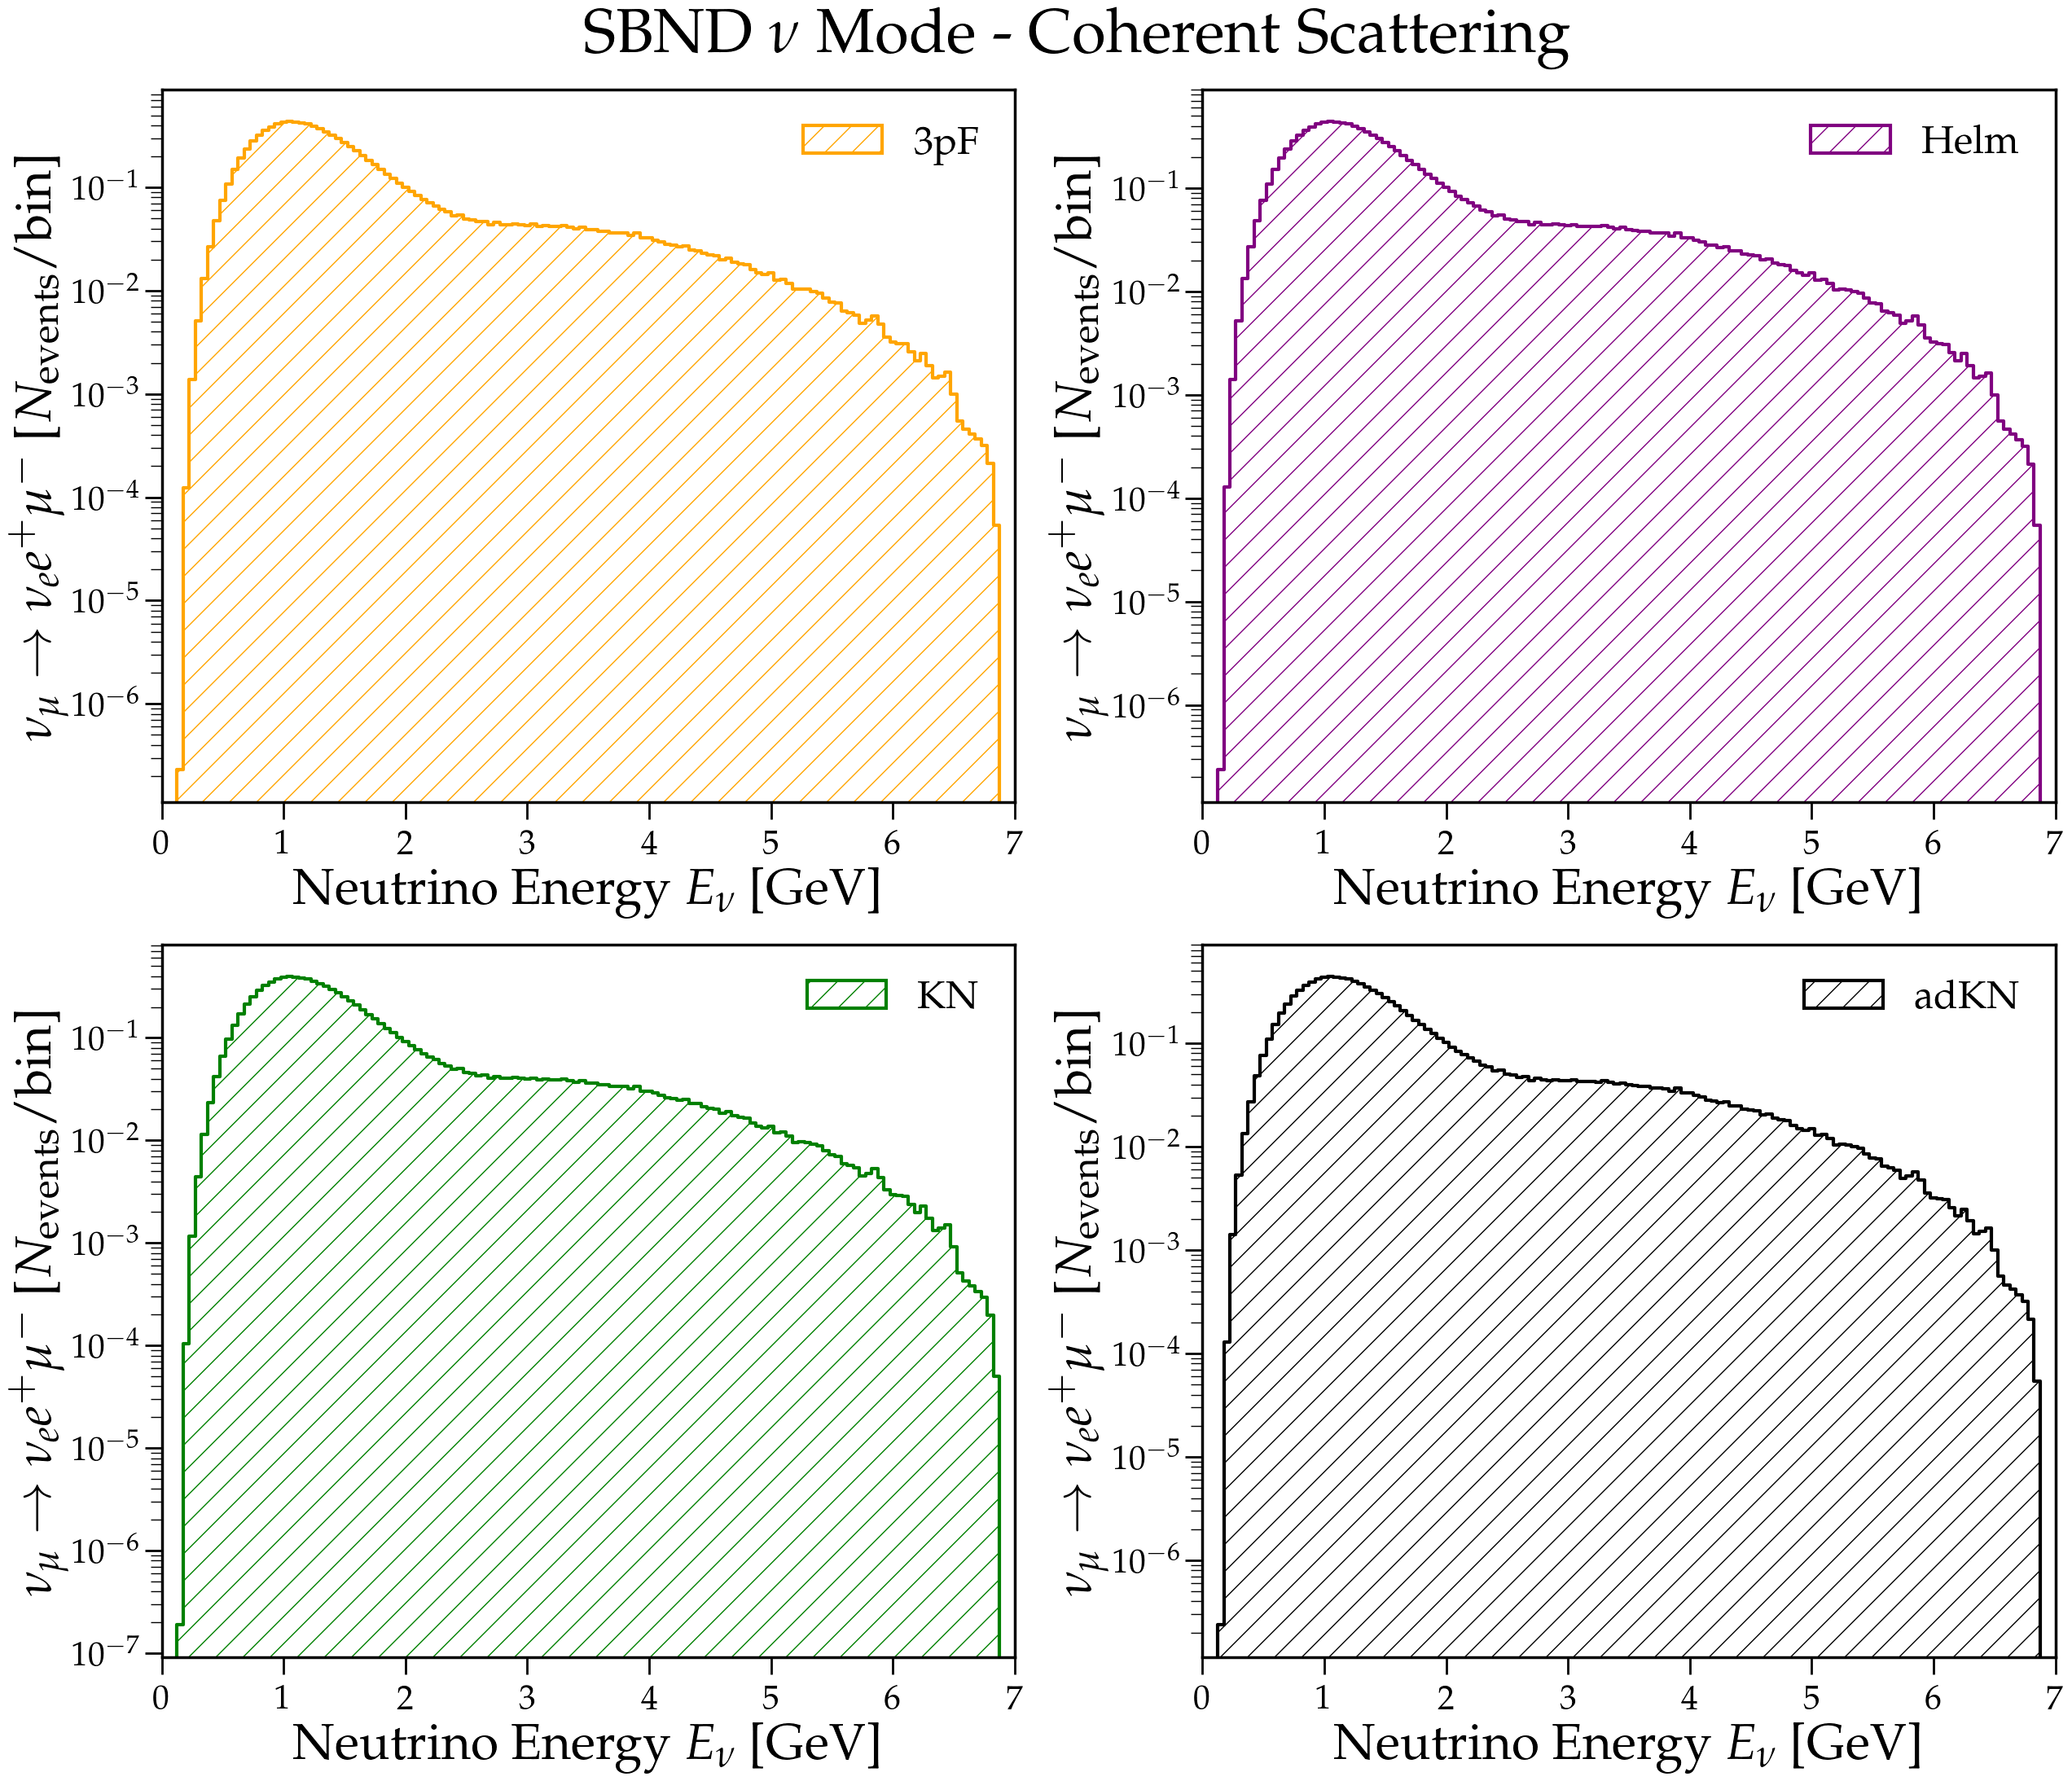

In [10]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> ve e+ mu- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_SBND_Numode_ve_e_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_ve_e_mu_coh_Ar_3pF, Xsec_ve_e_mu_coh_Ar_3pF, POT=1, MD=112)
Events_SBND_Numode_ve_e_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_ve_e_mu_coh_Ar_Helm, Xsec_ve_e_mu_coh_Ar_Helm, POT=1, MD=112)
Events_SBND_Numode_ve_e_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_ve_e_mu_coh_Ar_KN, Xsec_ve_e_mu_coh_Ar_KN, POT=1, MD=112)
Events_SBND_Numode_ve_e_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_ve_e_mu_coh_Ar_adKN, Xsec_ve_e_mu_coh_Ar_adKN, POT=1, MD=112)

ax1.bar(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_ve_e_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,7])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_e e^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'SBND $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/SBND_events_per_bin_ve_e+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/SBND_events_per_bin_ve_e+_mu-.png', bbox_inches='tight', transparent=False)

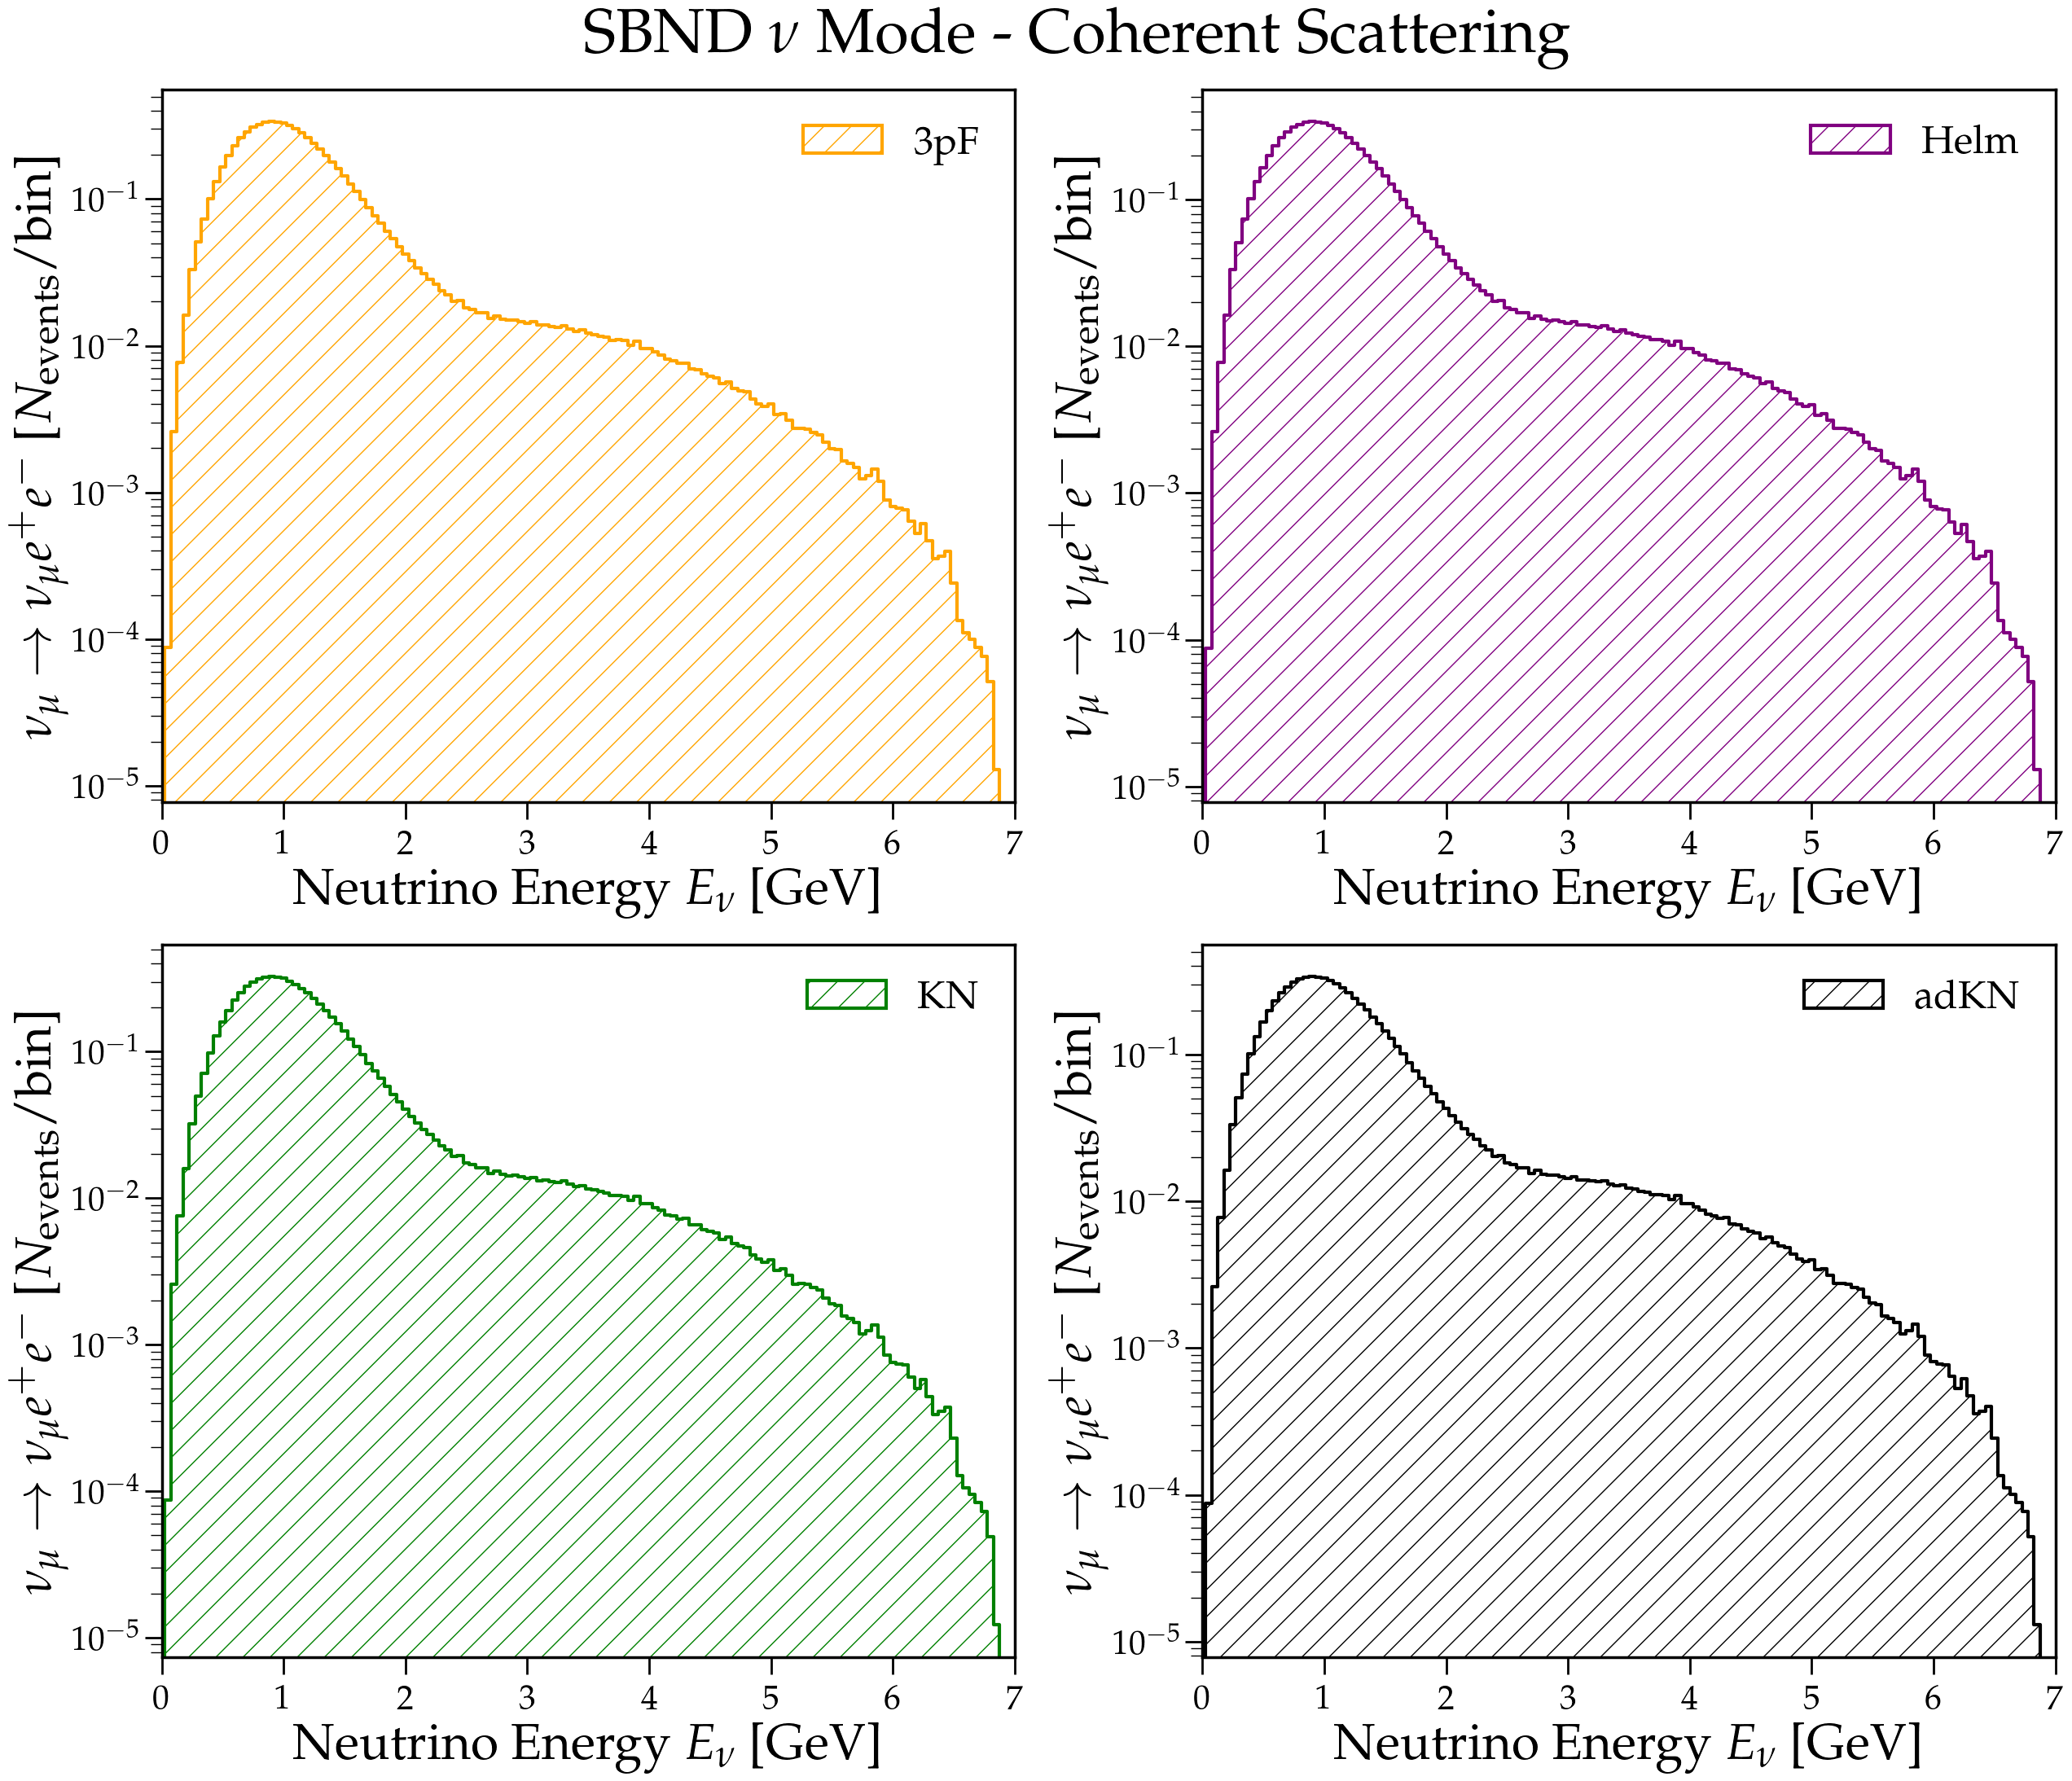

In [11]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vmu e+ e- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_SBND_Numode_vmu_e_e_coh_Ar_3pF = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_e_e_coh_Ar_3pF, Xsec_vmu_e_e_coh_Ar_3pF, POT=1, MD=112)
Events_SBND_Numode_vmu_e_e_coh_Ar_Helm = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_e_e_coh_Ar_Helm, Xsec_vmu_e_e_coh_Ar_Helm, POT=1, MD=112)
Events_SBND_Numode_vmu_e_e_coh_Ar_KN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_e_e_coh_Ar_KN, Xsec_vmu_e_e_coh_Ar_KN, POT=1, MD=112)
Events_SBND_Numode_vmu_e_e_coh_Ar_adKN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_e_e_coh_Ar_adKN, Xsec_vmu_e_e_coh_Ar_adKN, POT=1, MD=112)

ax1.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_e_e_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,7])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu e^{+} e^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'SBND $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/SBND_events_per_bin_vmu_e+_e-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/SBND_events_per_bin_vmu_e+_e-.png', bbox_inches='tight', transparent=False)

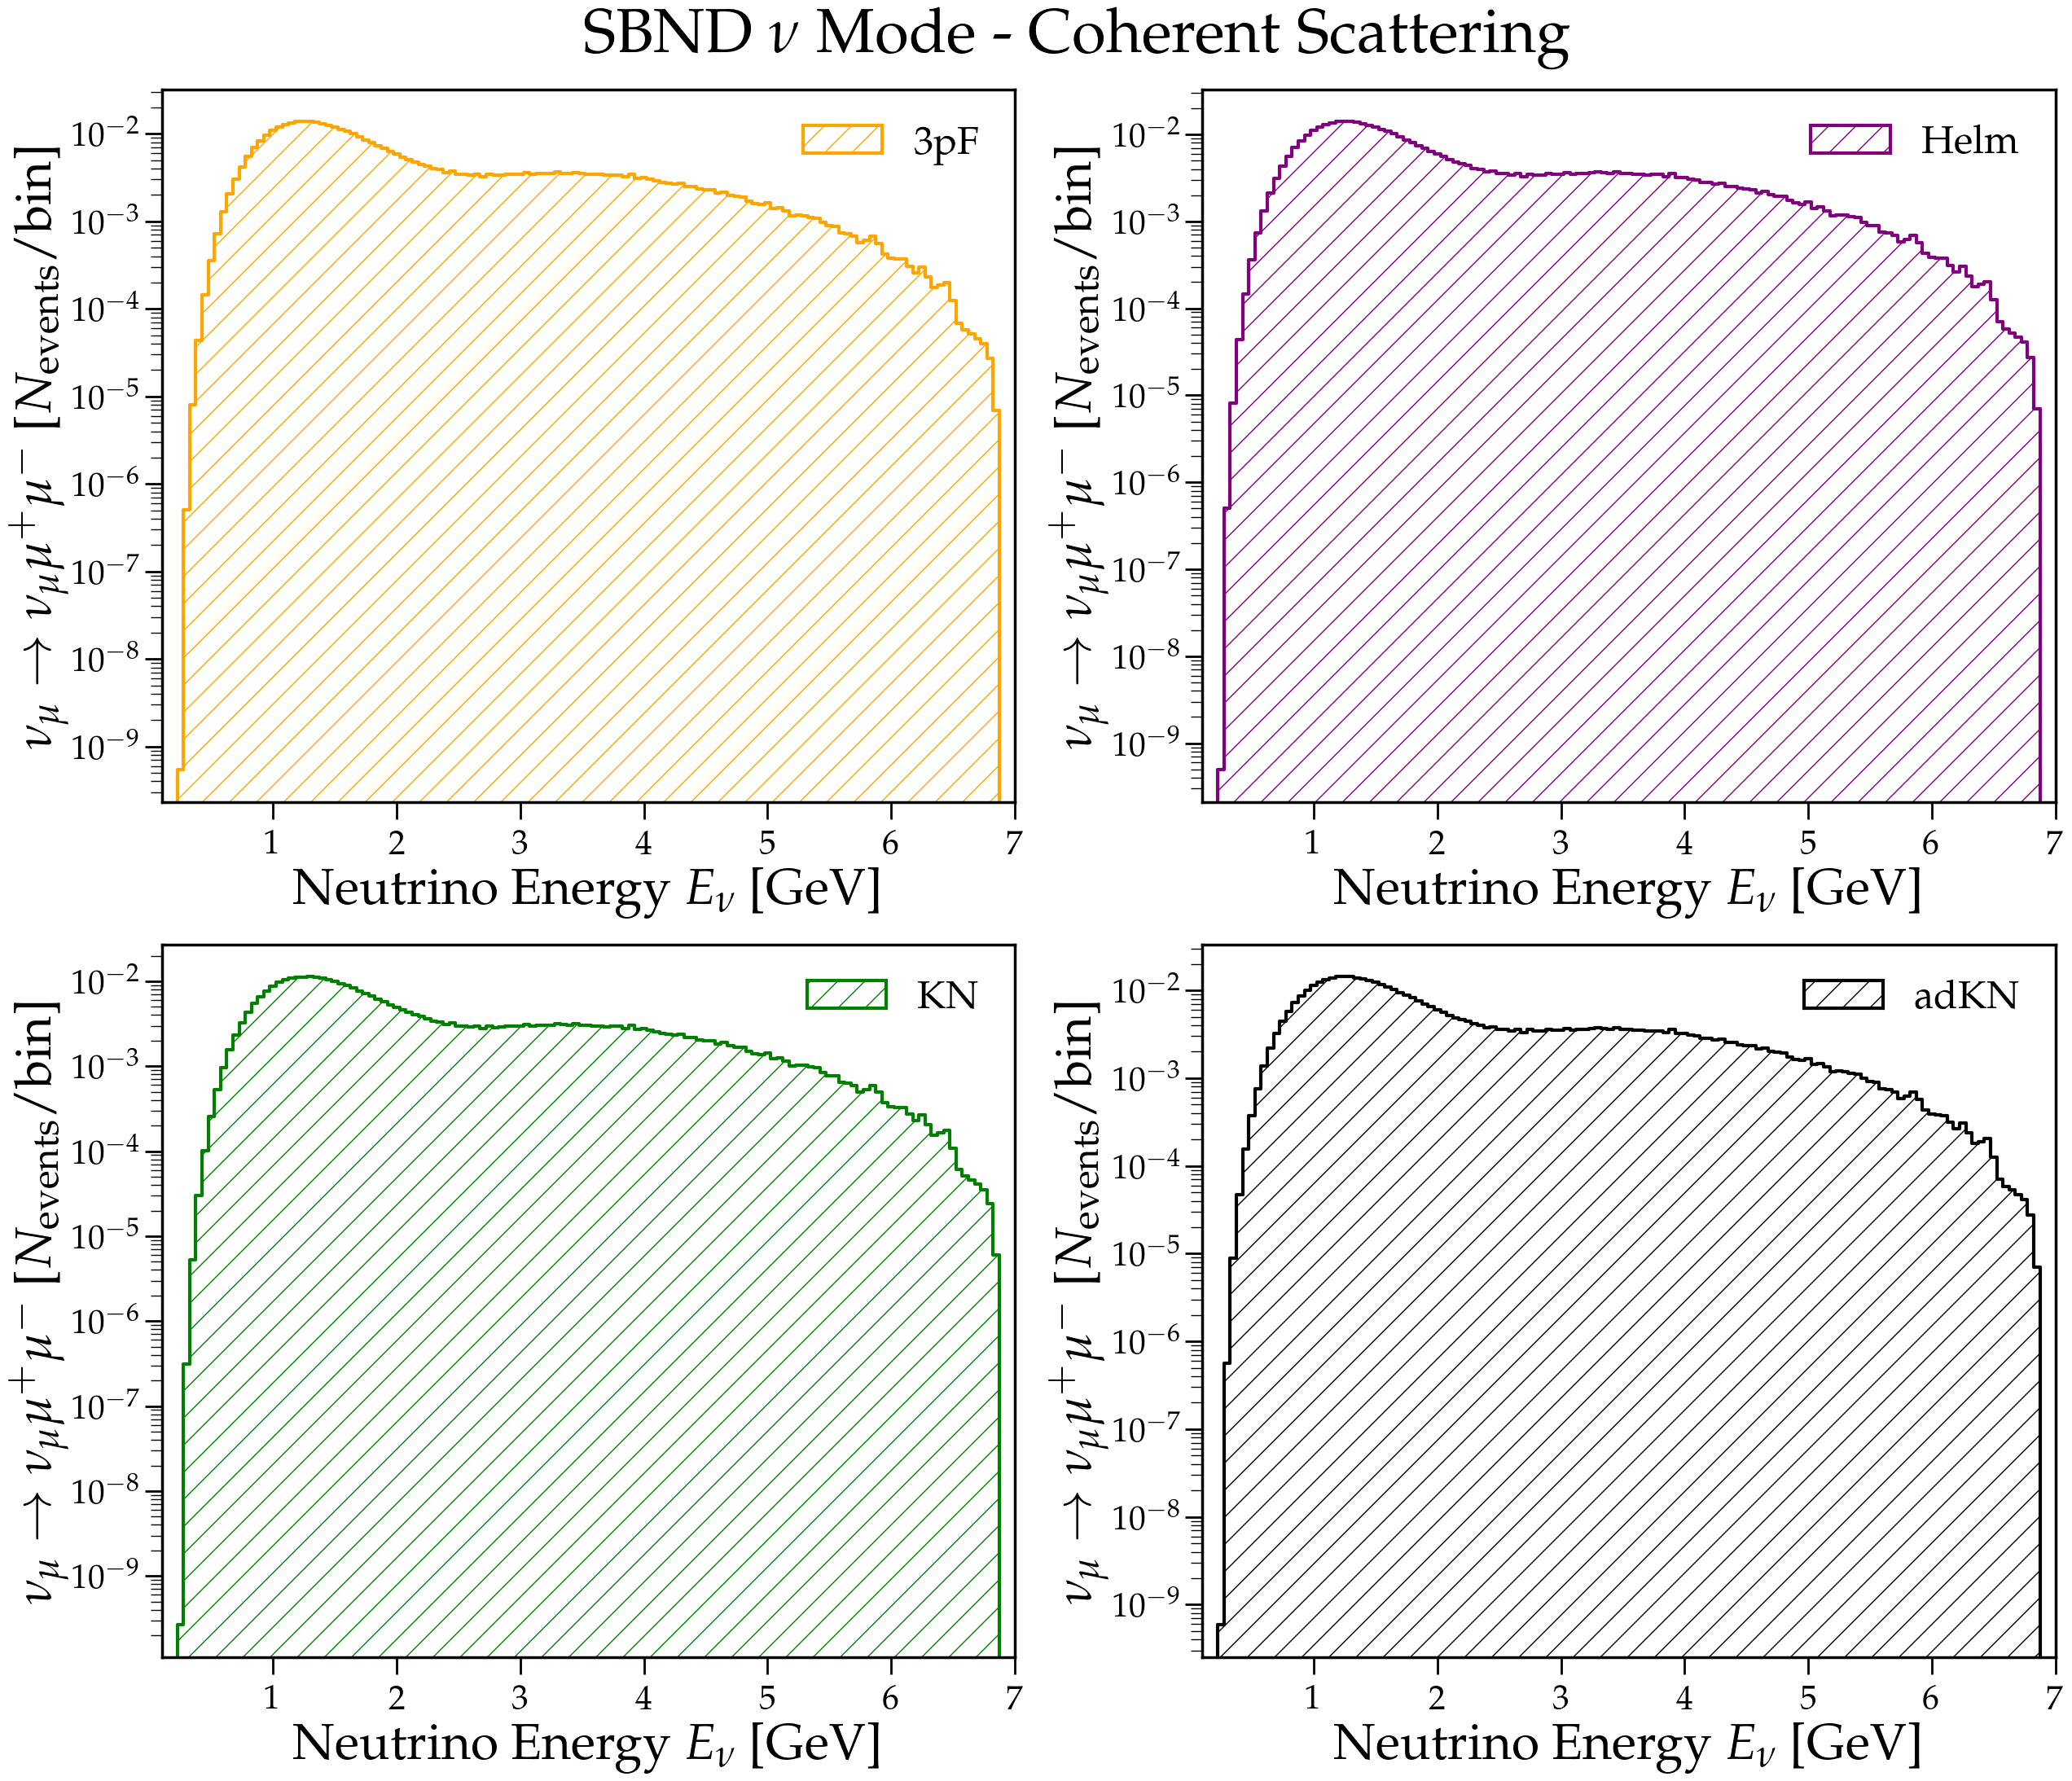

In [12]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vmu mu+ mu- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_SBND_Numode_vmu_mu_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_mu_mu_coh_Ar_3pF, Xsec_vmu_mu_mu_coh_Ar_3pF, POT=1, MD=112)
Events_SBND_Numode_vmu_mu_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_mu_mu_coh_Ar_Helm, Xsec_vmu_mu_mu_coh_Ar_Helm, POT=1, MD=112)
Events_SBND_Numode_vmu_mu_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_mu_mu_coh_Ar_KN, Xsec_vmu_mu_mu_coh_Ar_KN, POT=1, MD=112)
Events_SBND_Numode_vmu_mu_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_mu_mu_coh_Ar_adKN, Xsec_vmu_mu_mu_coh_Ar_adKN, POT=1, MD=112)

ax1.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_mu_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0.1,7])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'SBND $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/SBND_events_per_bin_vmu_mu+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/SBND_events_per_bin_vmu_mu+_mu-.png', bbox_inches='tight', transparent=False)

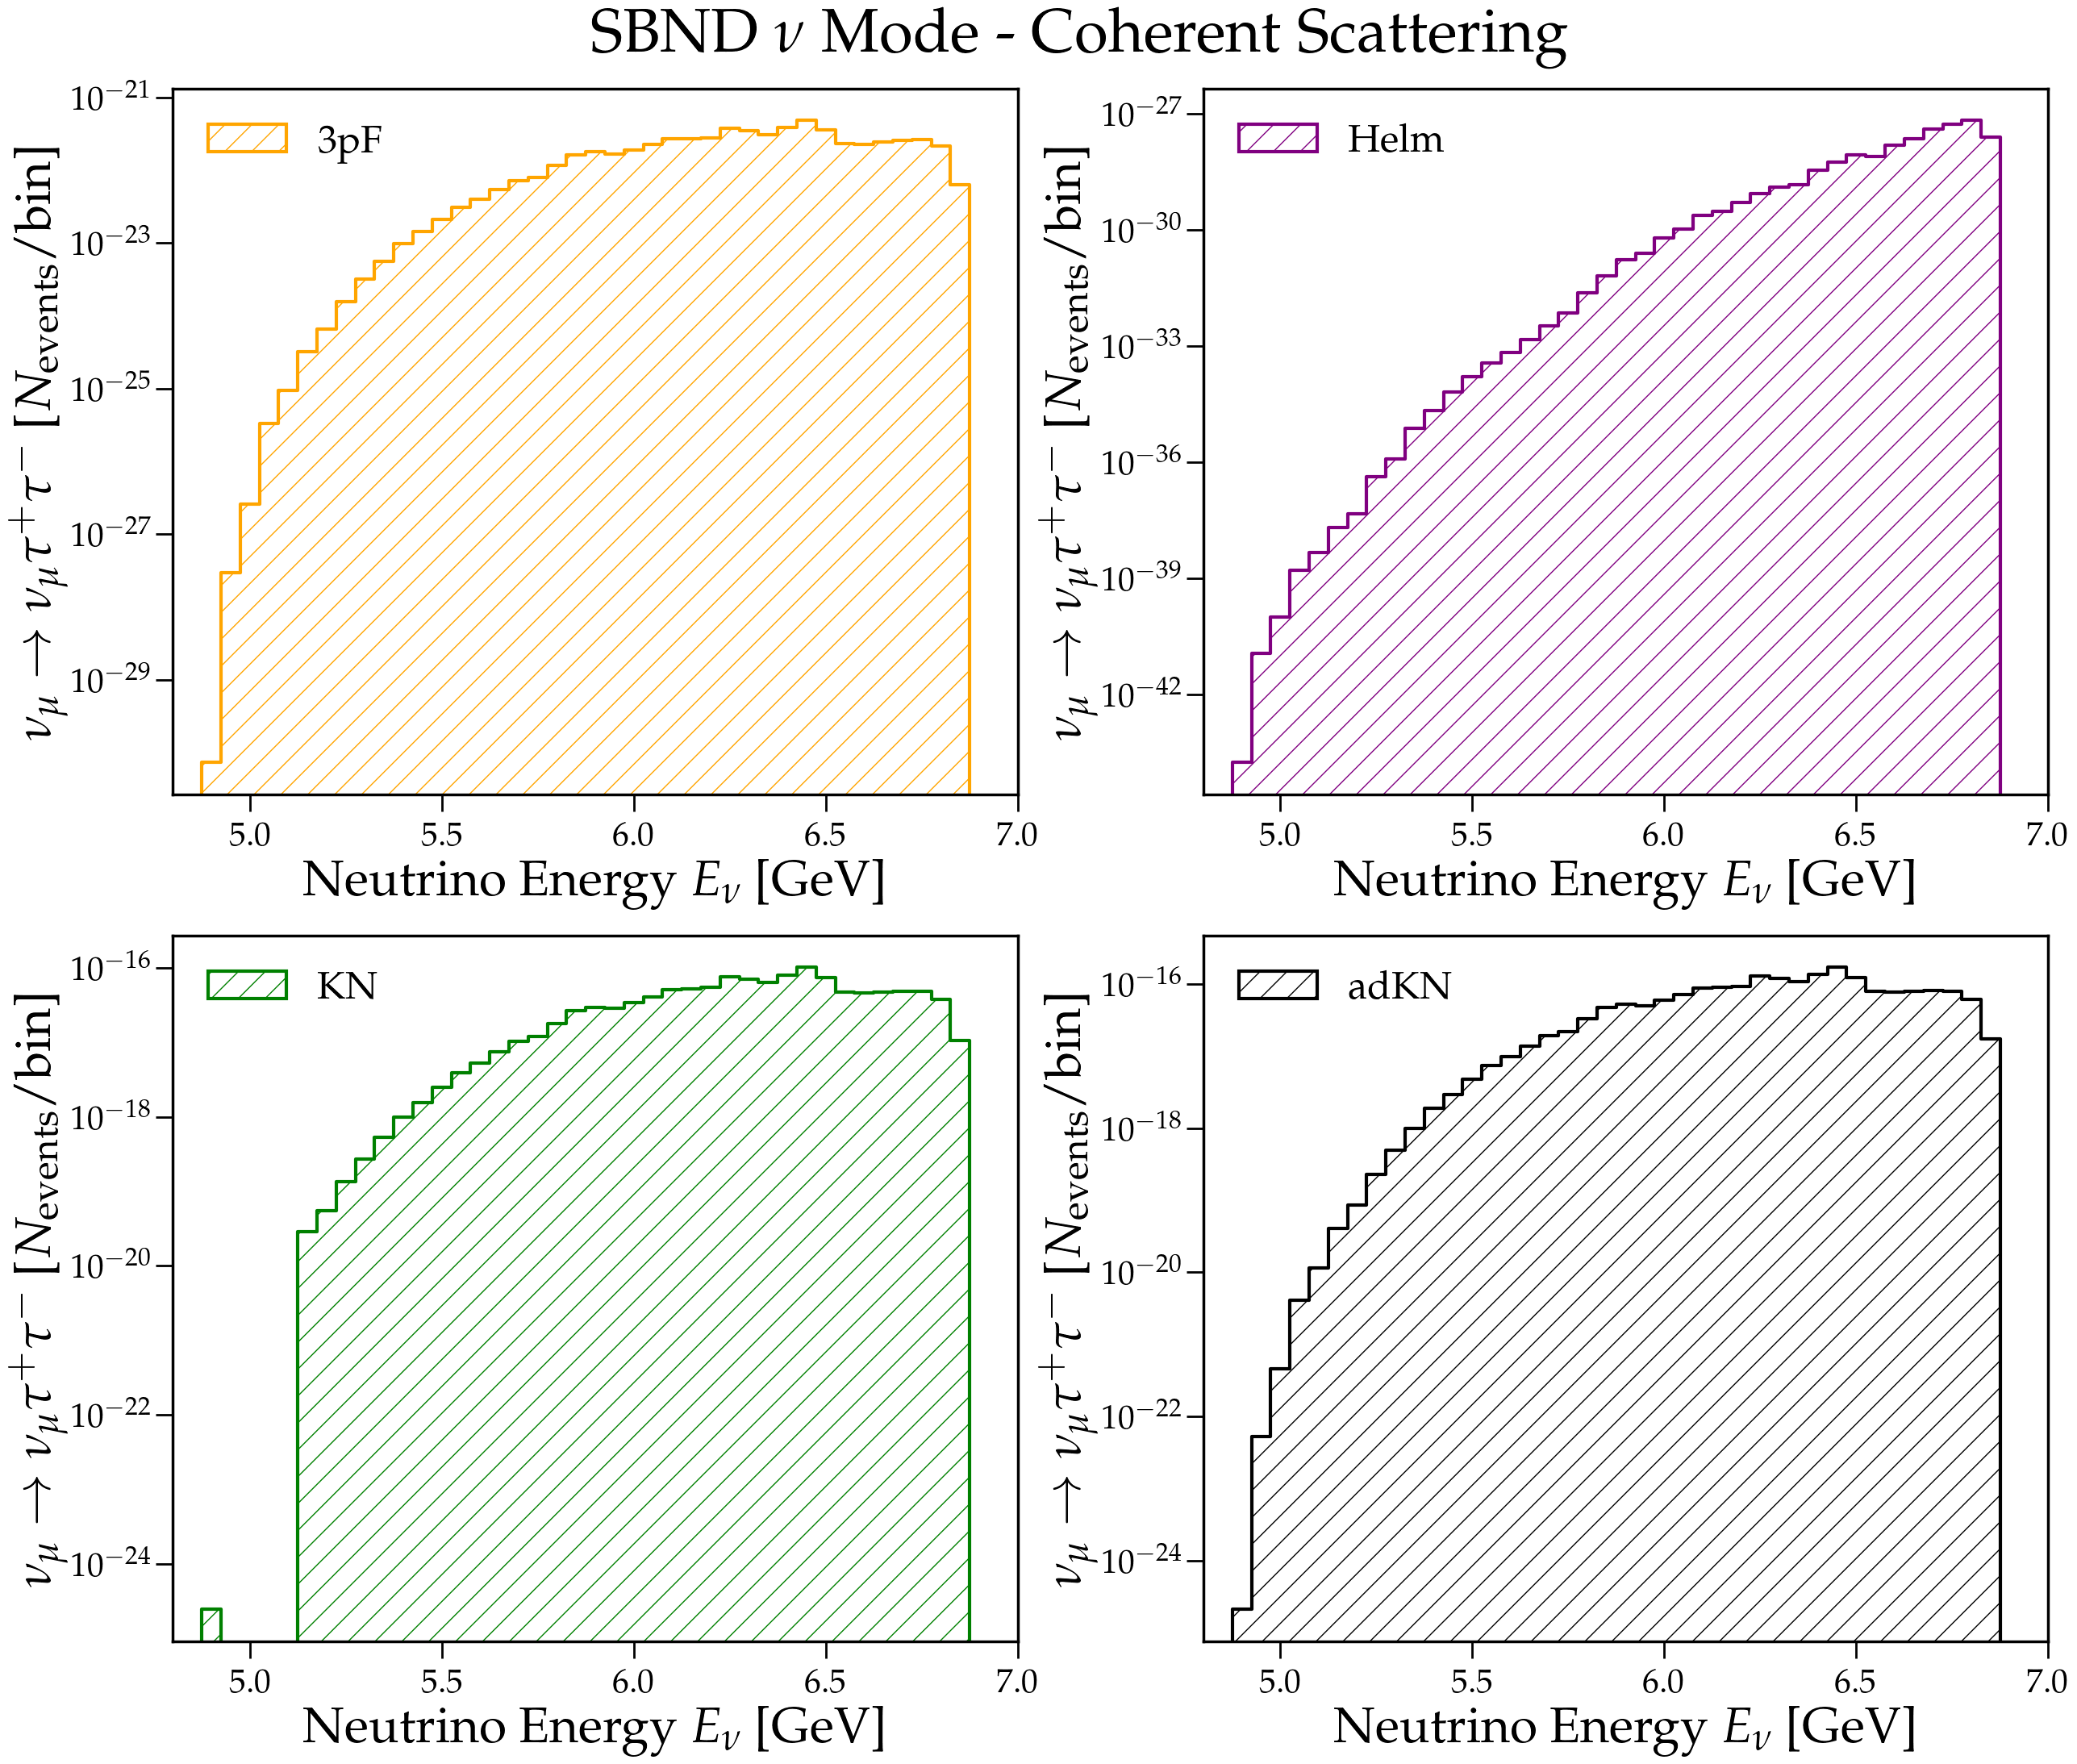

In [13]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vmu tau+ tau- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_SBND_Numode_vmu_tau_tau_coh_Ar_3pF = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_tau_tau_coh_Ar_3pF, Xsec_vmu_tau_tau_coh_Ar_3pF, POT=1, MD=112)
Events_SBND_Numode_vmu_tau_tau_coh_Ar_Helm = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_tau_tau_coh_Ar_Helm, Xsec_vmu_tau_tau_coh_Ar_Helm, POT=1, MD=112)
Events_SBND_Numode_vmu_tau_tau_coh_Ar_KN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_tau_tau_coh_Ar_KN, Xsec_vmu_tau_tau_coh_Ar_KN, POT=1, MD=112)
Events_SBND_Numode_vmu_tau_tau_coh_Ar_adKN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vmu_tau_tau_coh_Ar_adKN, Xsec_vmu_tau_tau_coh_Ar_adKN, POT=1, MD=112)

ax1.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vmu_tau_tau_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([4.8,7])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'SBND $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/SBND_events_per_bin_vmu_tau+_tau-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/SBND_events_per_bin_vmu_tau+_tau-.png', bbox_inches='tight', transparent=False)

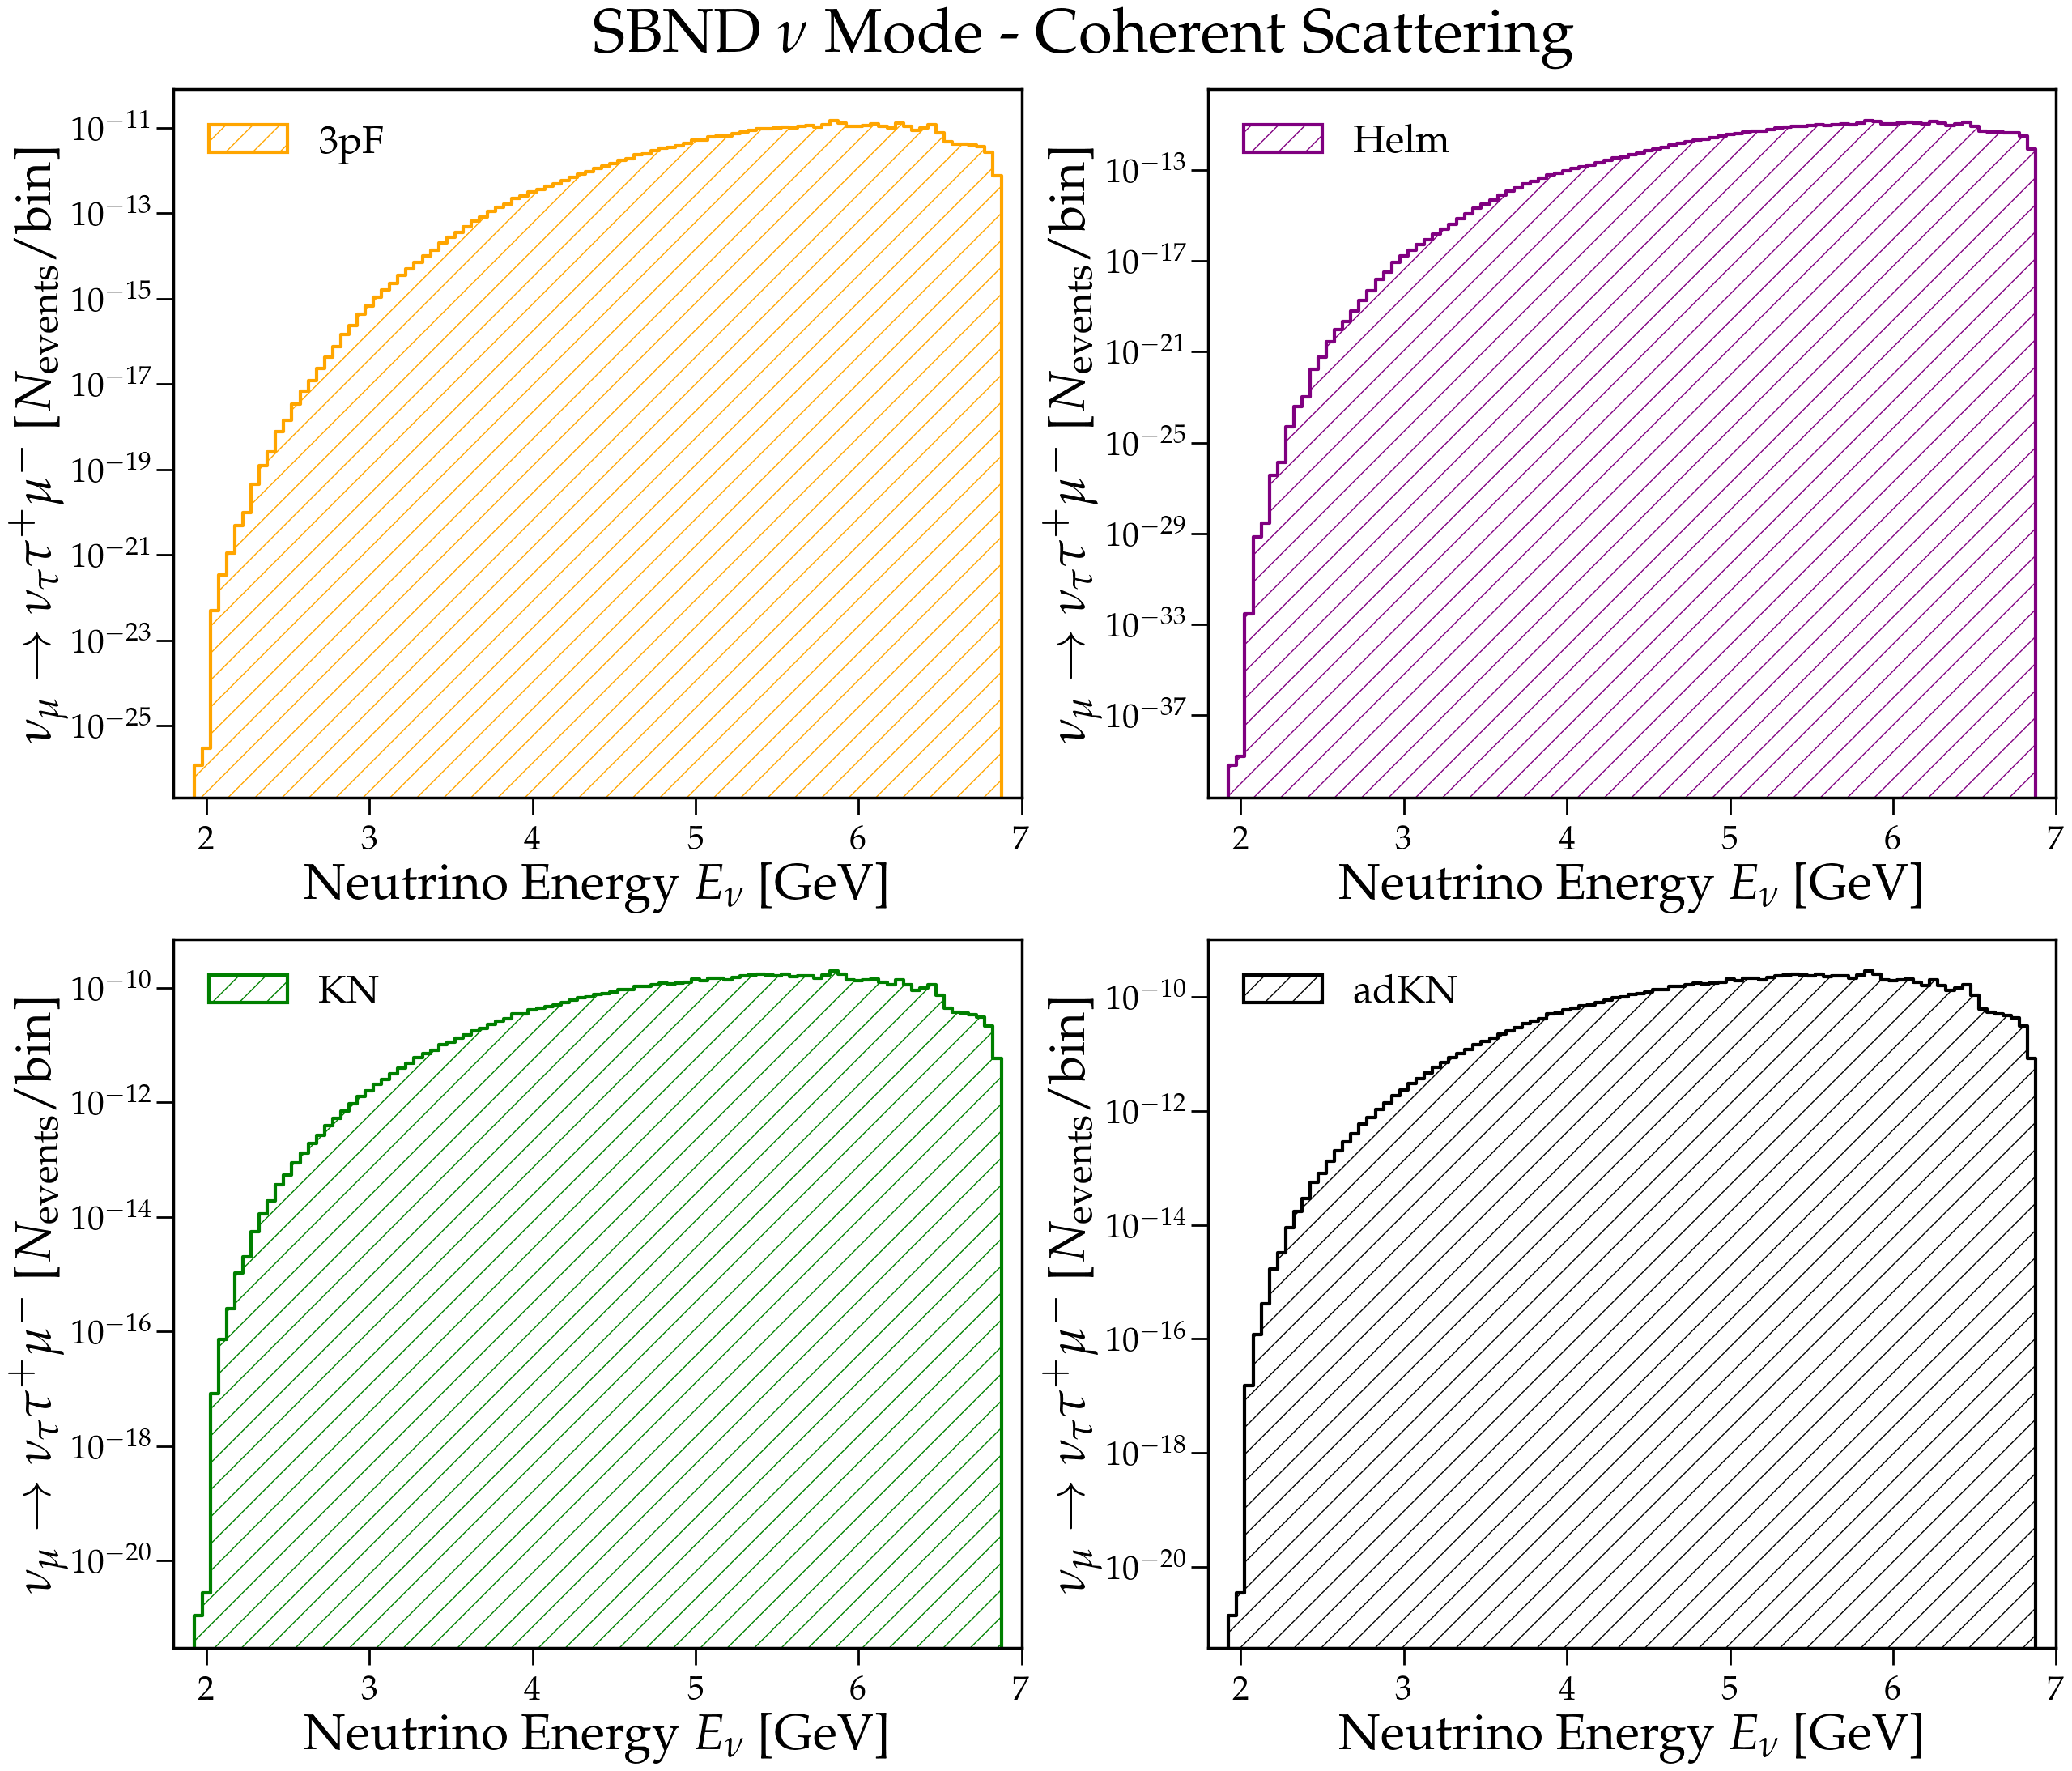

In [14]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vtau tau+ mu- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_SBND_Numode_vtau_tau_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vtau_tau_mu_coh_Ar_3pF, Xsec_vtau_tau_mu_coh_Ar_3pF, POT=1, MD=112)
Events_SBND_Numode_vtau_tau_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vtau_tau_mu_coh_Ar_Helm, Xsec_vtau_tau_mu_coh_Ar_Helm, POT=1, MD=112)
Events_SBND_Numode_vtau_tau_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vtau_tau_mu_coh_Ar_KN, Xsec_vtau_tau_mu_coh_Ar_KN, POT=1, MD=112)
Events_SBND_Numode_vtau_tau_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_SBND_NuMode, Enu_SBND_NuMode, Energy_vtau_tau_mu_coh_Ar_adKN, Xsec_vtau_tau_mu_coh_Ar_adKN, POT=1, MD=112)

ax1.bar(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_3pF, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_Helm, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_KN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_adKN, width=0.05, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_SBND_NuMode, Events_SBND_Numode_vtau_tau_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([1.8,7])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'SBND $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/SBND_events_per_bin_vtau_tau+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/SBND_events_per_bin_vtau_tau+_mu-.png', bbox_inches='tight', transparent=False)

# Event Distribution at DUNE Std. (Neutrino Flux - Neutrino Mode)

In [3]:
####################################################################################################################
################################ Flux at DUNE Std Neutrino Mode ###################################################
####################################################################################################################
Elow_DUNEStd_NuMode = np.loadtxt("../csv/Fluxes/NormProb/nu_NormProb_DUNEStd_nuMode.txt", delimiter=',', usecols=0, comments="#") # GeV
Ehigh_DUNEStd_NuMode = np.loadtxt("../csv/Fluxes/NormProb/nu_NormProb_DUNEStd_nuMode.txt", delimiter=',', usecols=1, comments="#") # GeV
Flux_DUNEStd_NuMode = np.loadtxt("../csv/Fluxes/histos_g4lbne_v3r5p4_QGSP_BERT_OptimizedEngineeredNov2017_neutrino_LBNEND_globes_flux.txt", usecols=2, comments="#") # numu/m^2/POT/GeV
Enu_DUNEStd_NuMode = (Elow_DUNEStd_NuMode + Ehigh_DUNEStd_NuMode)/2

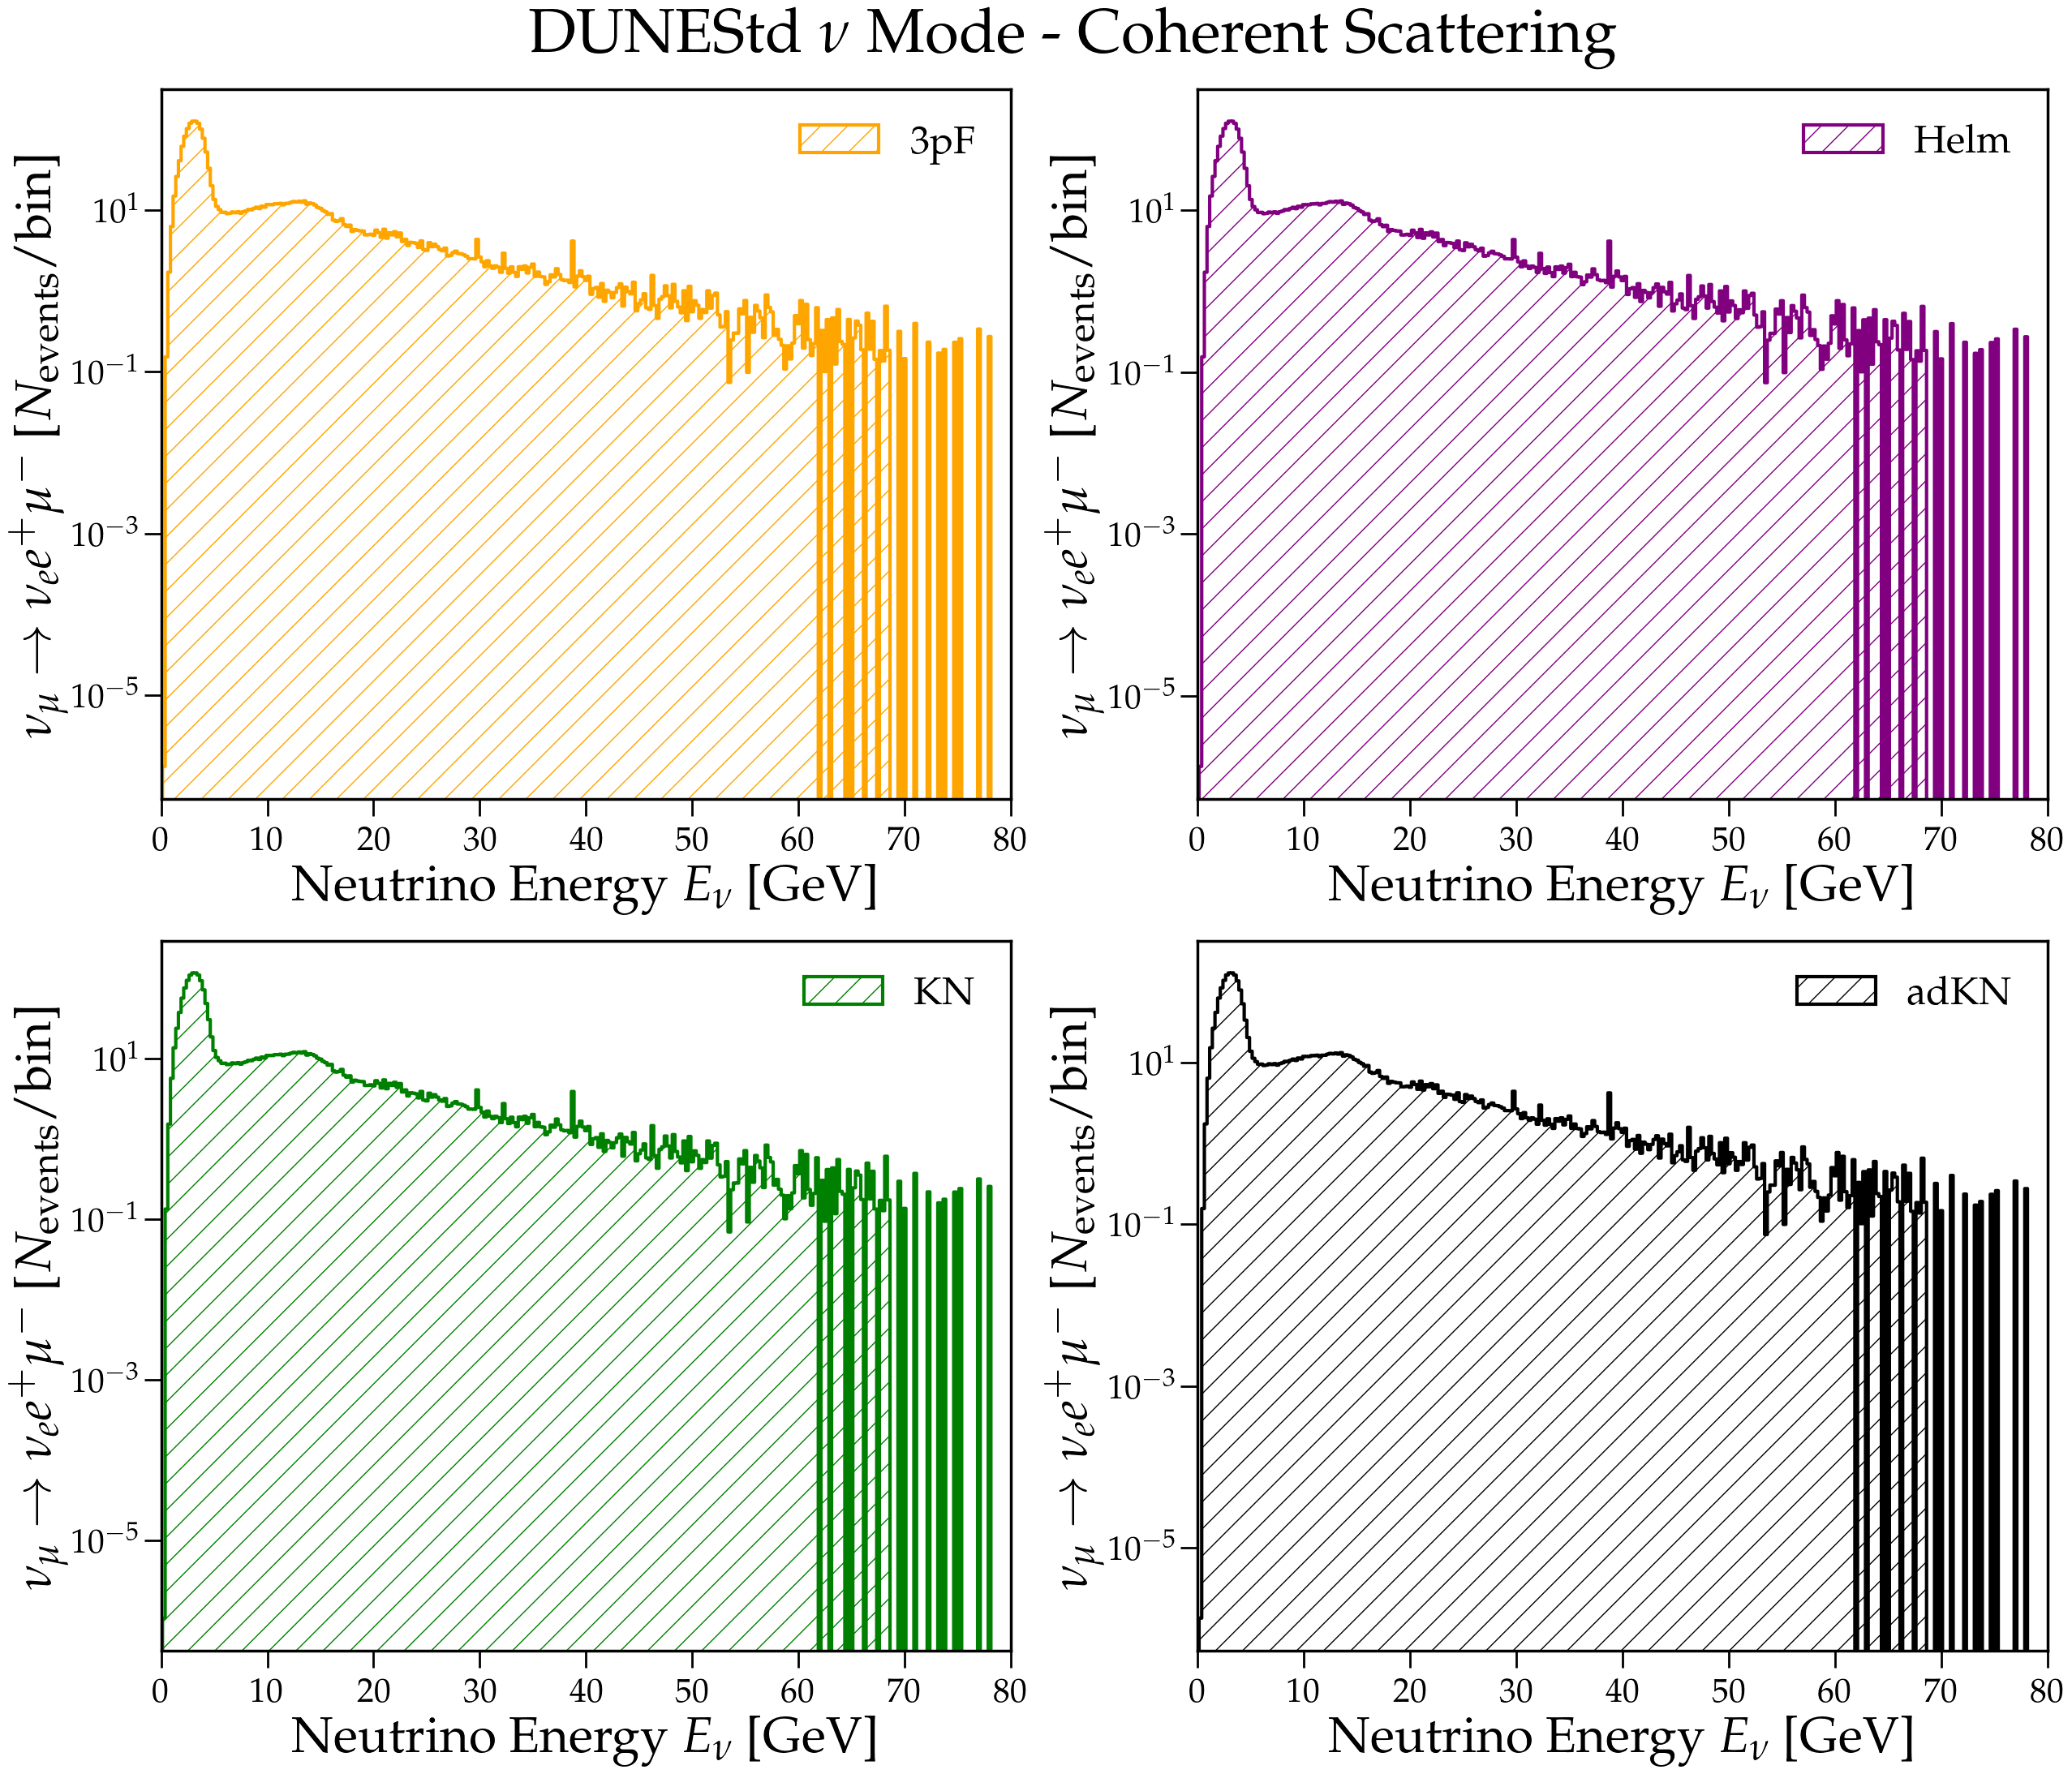

In [23]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> ve e+ mu- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_DUNEStd_Numode_ve_e_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_ve_e_mu_coh_Ar_3pF, Xsec_ve_e_mu_coh_Ar_3pF, POT=3.3, MD=67)
Events_DUNEStd_Numode_ve_e_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_ve_e_mu_coh_Ar_Helm, Xsec_ve_e_mu_coh_Ar_Helm, POT=3.3, MD=67)
Events_DUNEStd_Numode_ve_e_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_ve_e_mu_coh_Ar_KN, Xsec_ve_e_mu_coh_Ar_KN, POT=3.3, MD=67)
Events_DUNEStd_Numode_ve_e_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_ve_e_mu_coh_Ar_adKN, Xsec_ve_e_mu_coh_Ar_adKN, POT=3.3, MD=67)

ax1.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_3pF, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_Helm, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_KN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_adKN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_ve_e_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,80])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_e e^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'DUNEStd $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/DUNEStd_events_per_bin_ve_e+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/DUNEStd_events_per_bin_ve_e+_mu-.png', bbox_inches='tight', transparent=False)

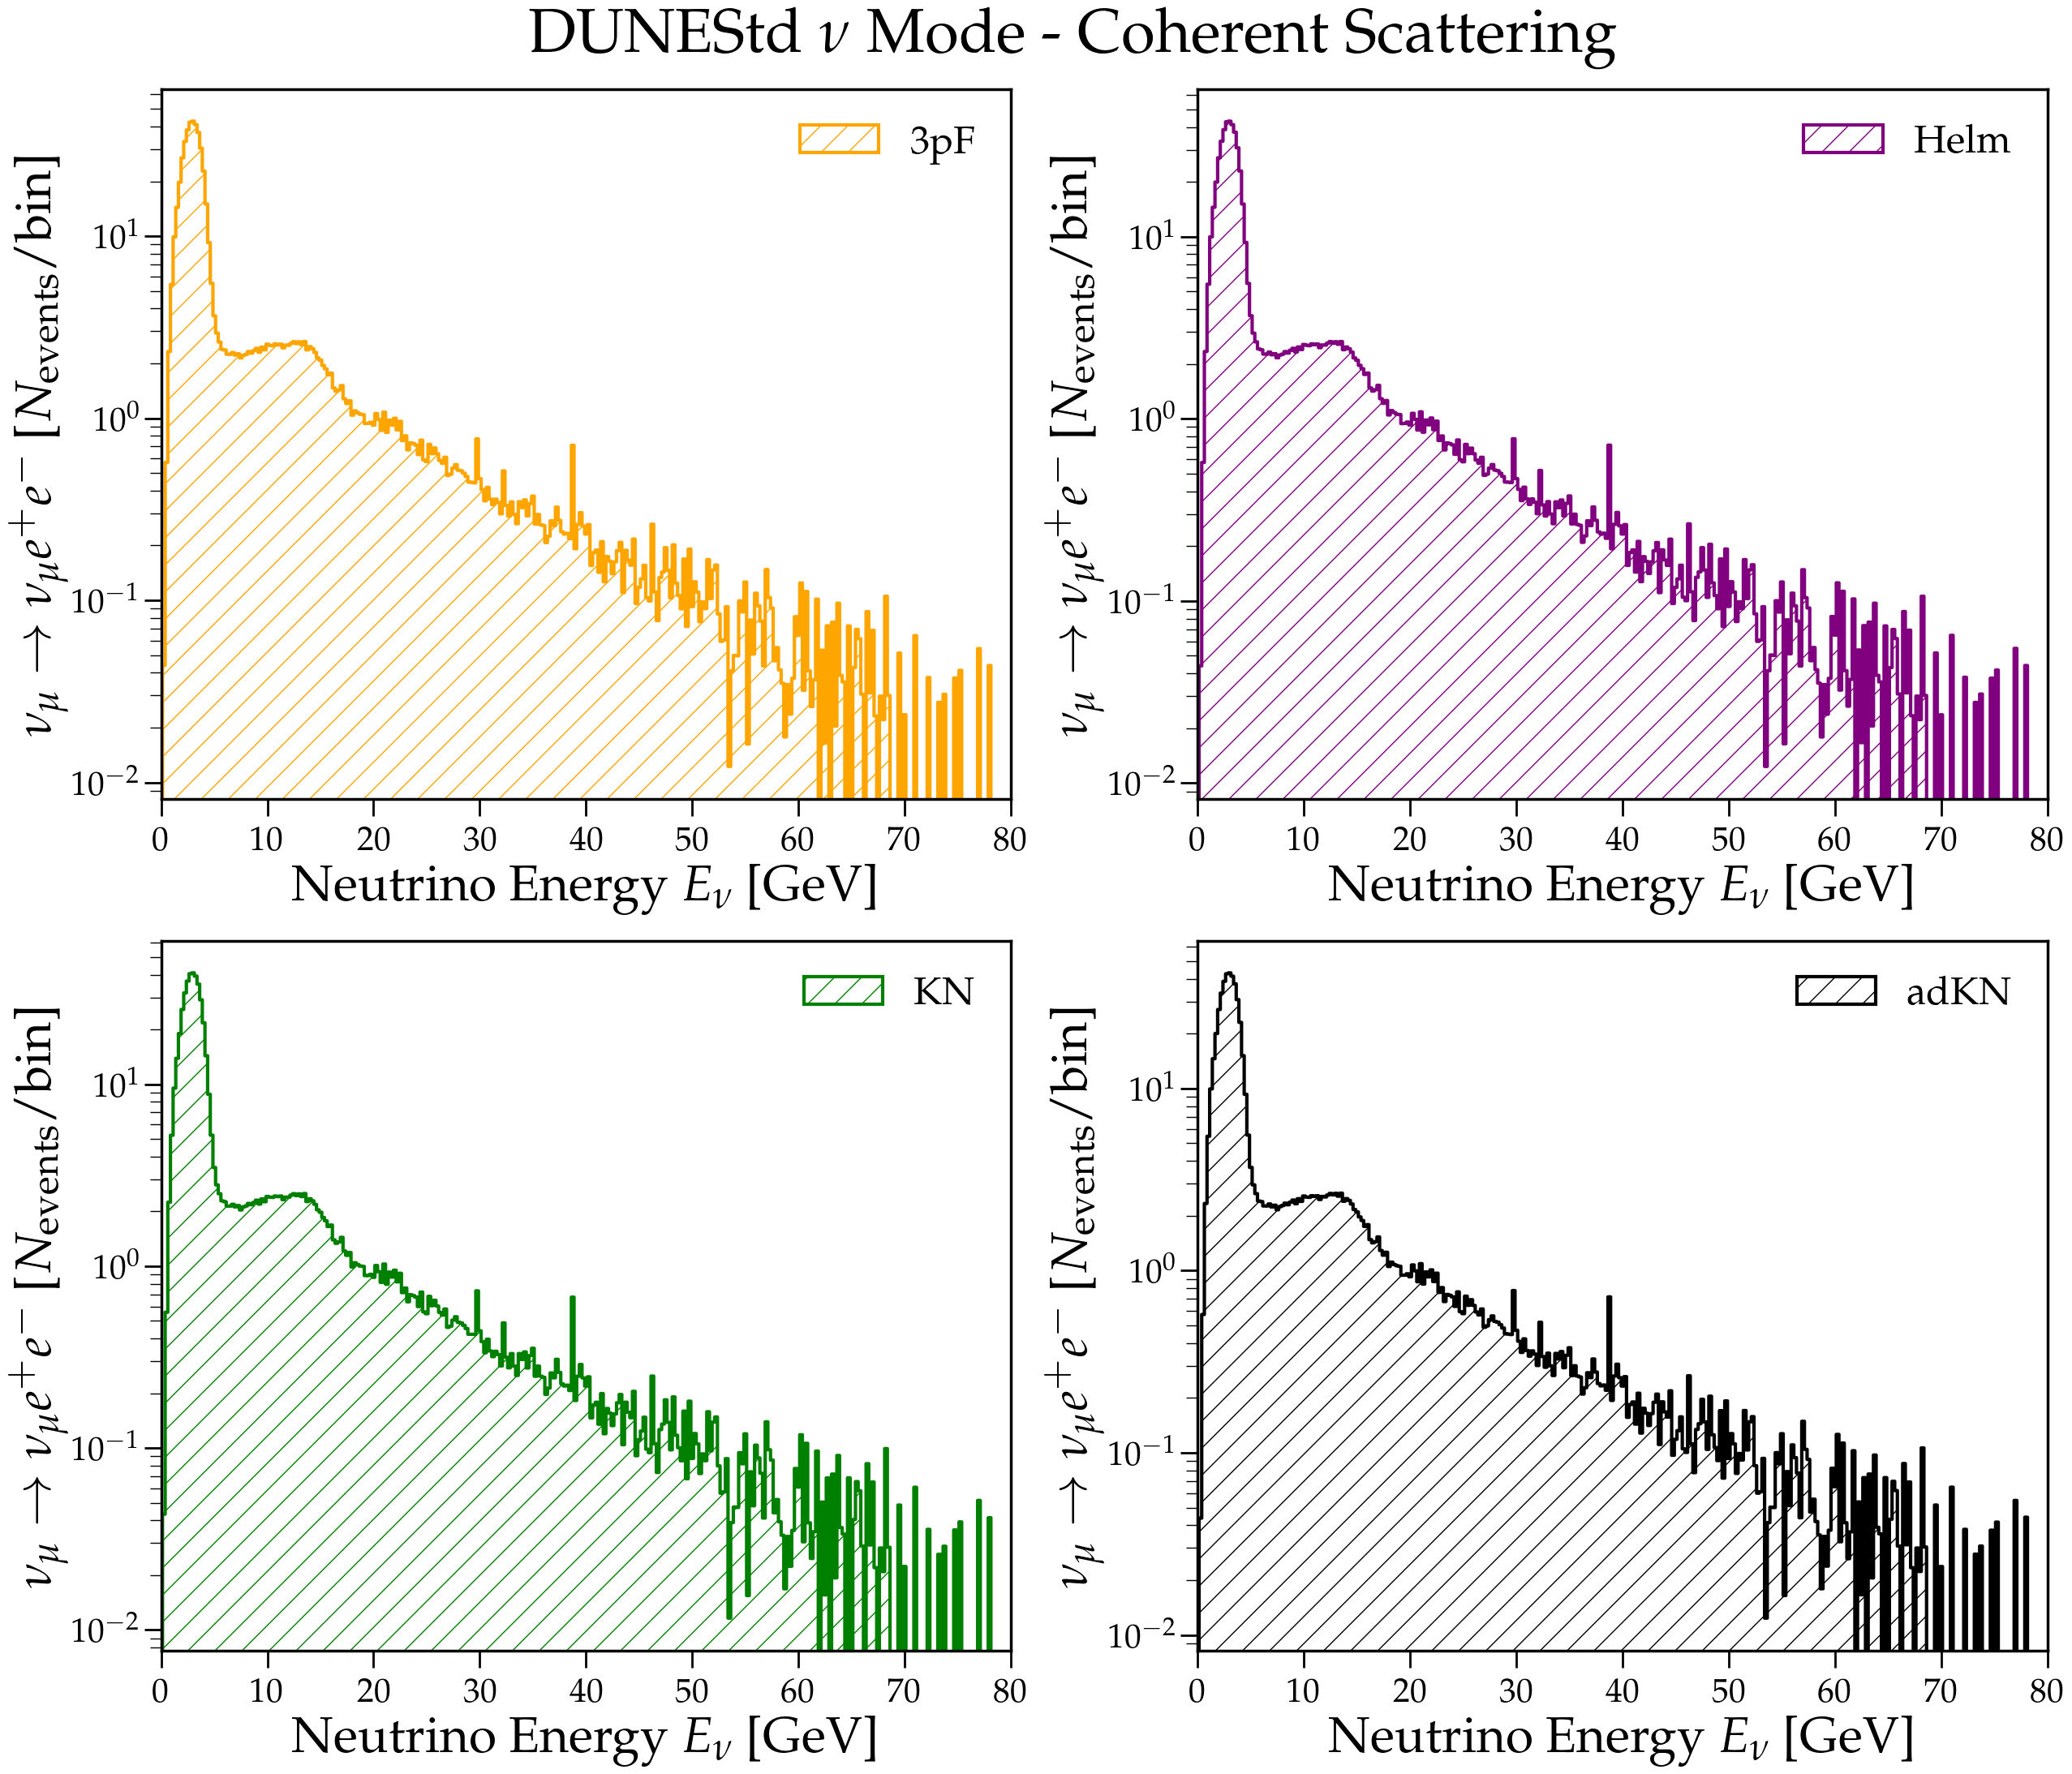

In [24]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vmu e+ e- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_DUNEStd_Numode_vmu_e_e_coh_Ar_3pF = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_e_e_coh_Ar_3pF, Xsec_vmu_e_e_coh_Ar_3pF, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_e_e_coh_Ar_Helm = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_e_e_coh_Ar_Helm, Xsec_vmu_e_e_coh_Ar_Helm, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_e_e_coh_Ar_KN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_e_e_coh_Ar_KN, Xsec_vmu_e_e_coh_Ar_KN, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_e_e_coh_Ar_adKN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_e_e_coh_Ar_adKN, Xsec_vmu_e_e_coh_Ar_adKN, POT=3.3, MD=67)

ax1.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_3pF, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_Helm, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_KN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_adKN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_e_e_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,80])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu e^{+} e^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'DUNEStd $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/DUNEStd_events_per_bin_vmu_e+_e-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/DUNEStd_events_per_bin_vmu_e+_e-.png', bbox_inches='tight', transparent=False)

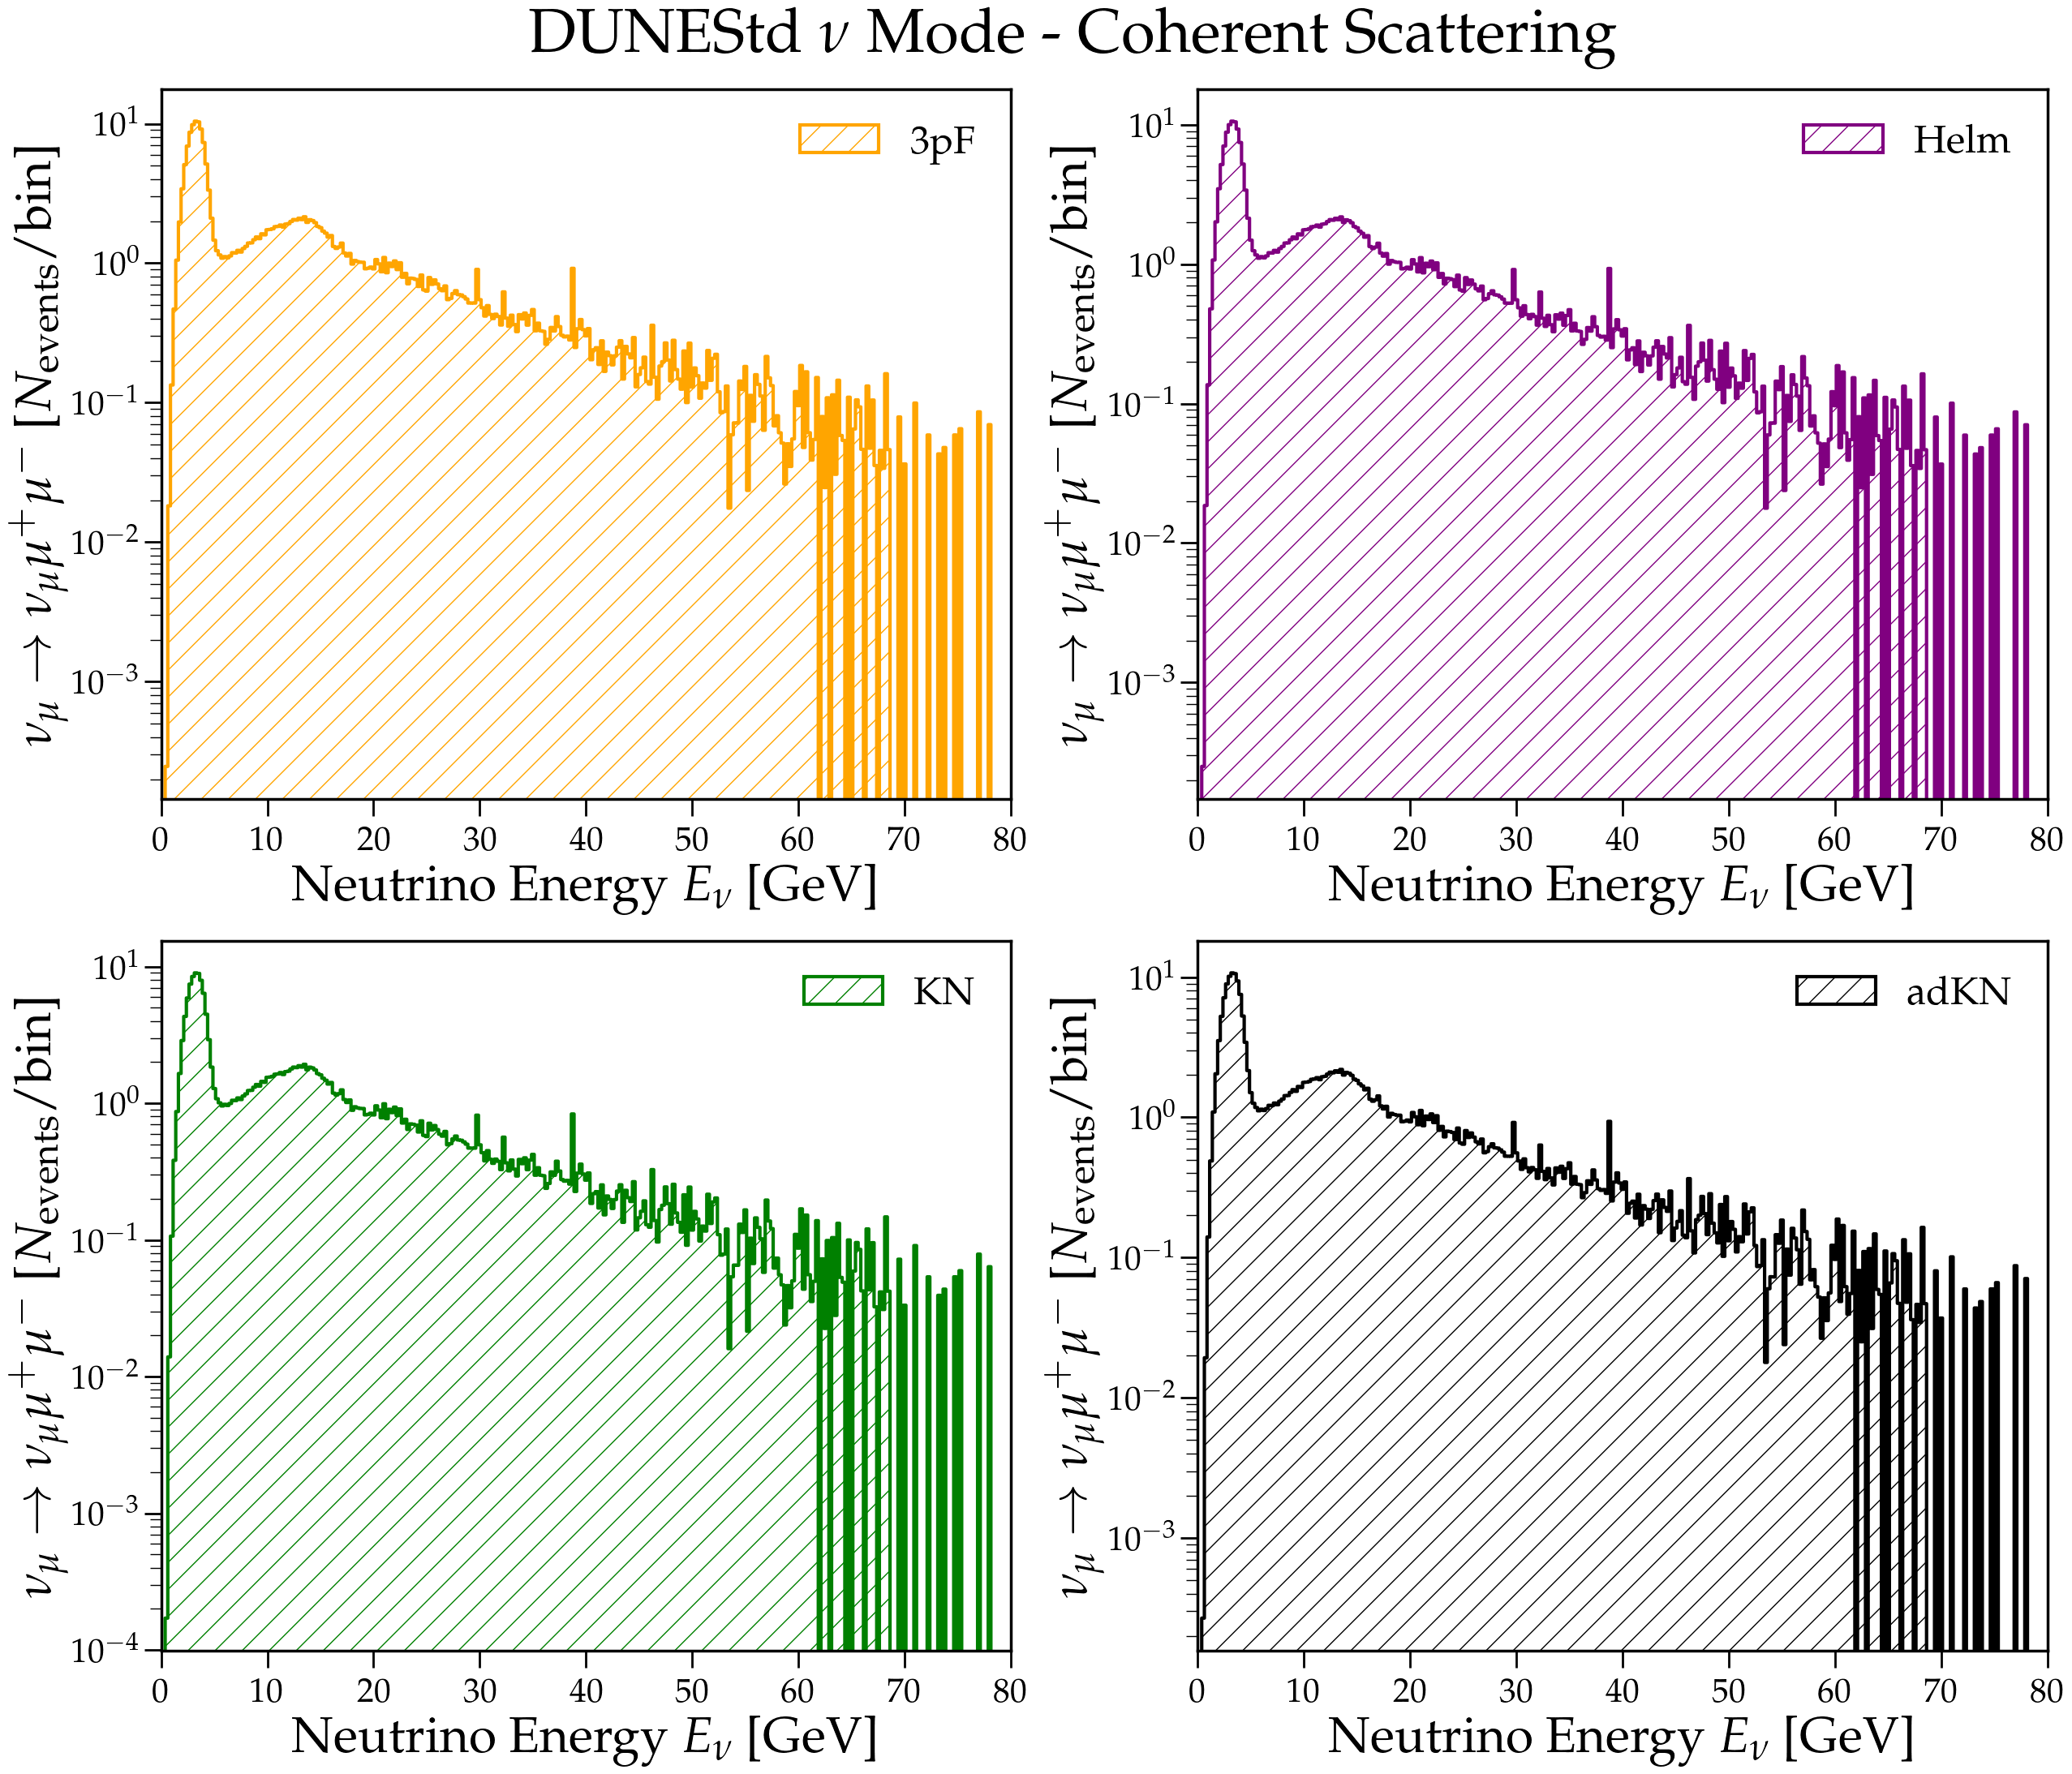

In [25]:
####################################################################################################################
########################### Cross Sections for the process: vmu -> vmu mu+ mu- #####################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_mu_mu_coh_Ar_3pF, Xsec_vmu_mu_mu_coh_Ar_3pF, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_mu_mu_coh_Ar_Helm, Xsec_vmu_mu_mu_coh_Ar_Helm, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_mu_mu_coh_Ar_KN, Xsec_vmu_mu_mu_coh_Ar_KN, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_mu_mu_coh_Ar_adKN, Xsec_vmu_mu_mu_coh_Ar_adKN, POT=3.3, MD=67)

ax1.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_3pF, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_Helm, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_KN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_adKN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_mu_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,80])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'DUNEStd $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/DUNEStd_events_per_bin_vmu_mu+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/DUNEStd_events_per_bin_vmu_mu+_mu-.png', bbox_inches='tight', transparent=False)

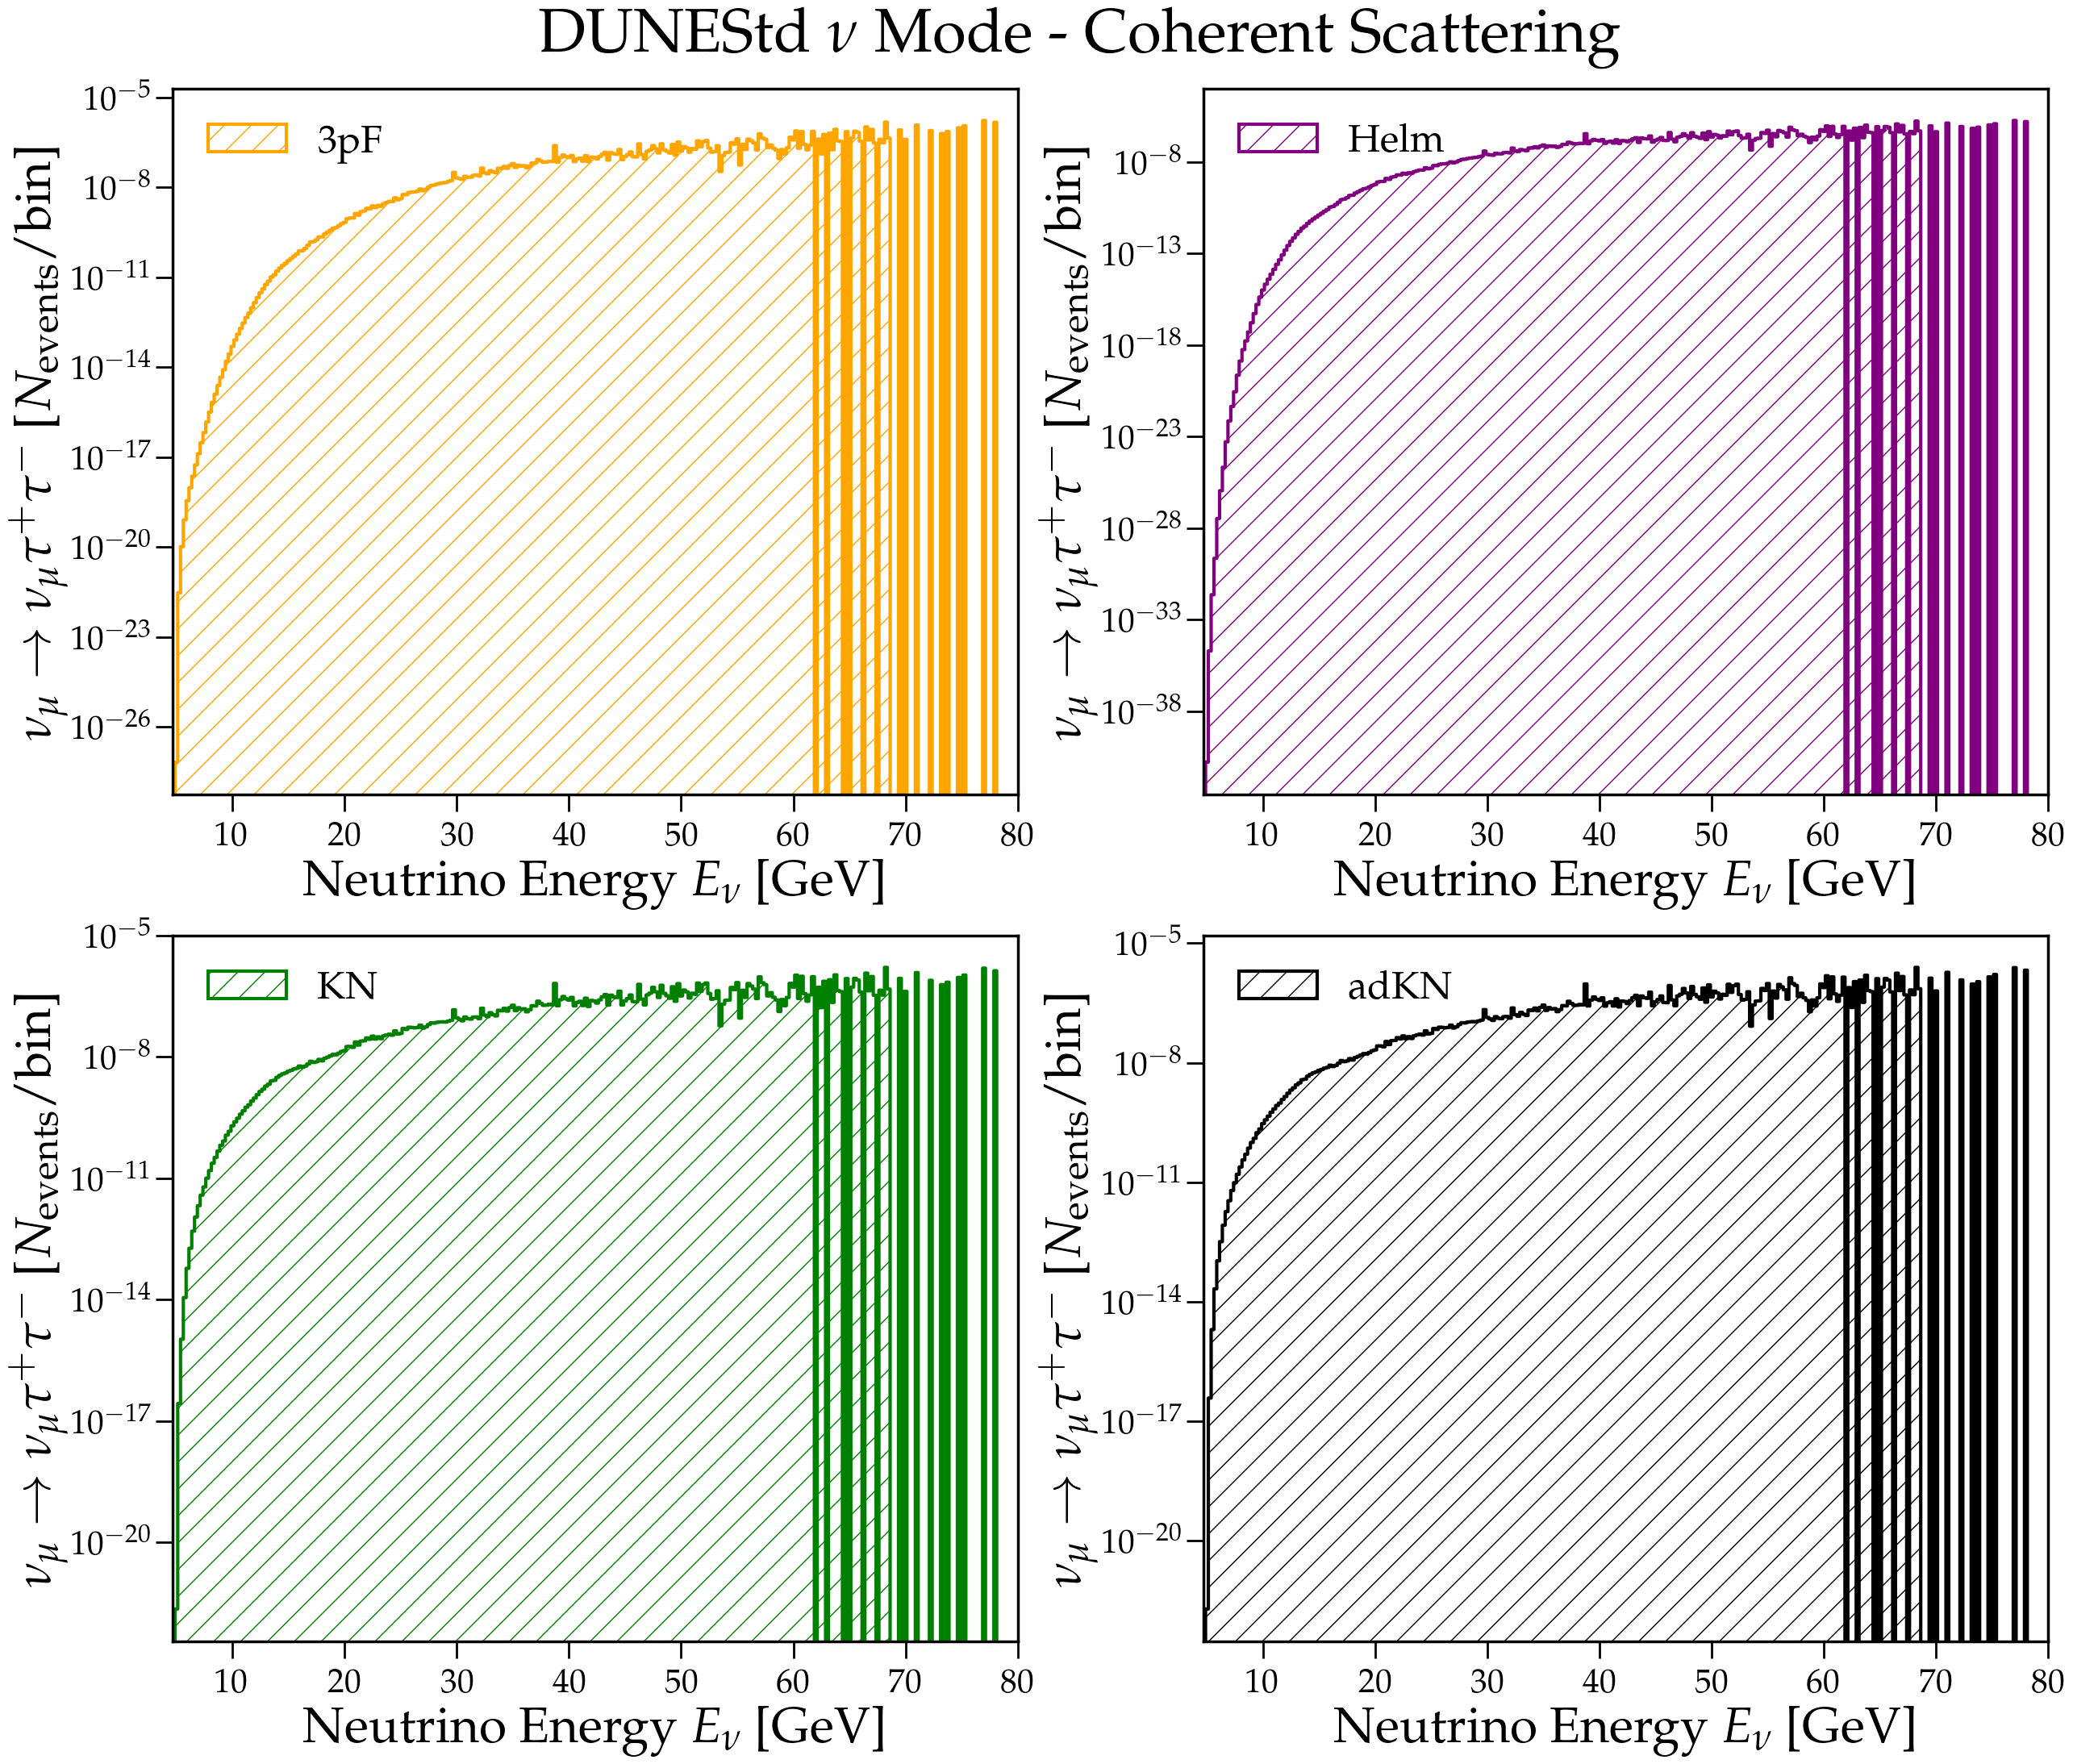

In [26]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vmu tau+ tau- ###################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_3pF = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_tau_tau_coh_Ar_3pF, Xsec_vmu_tau_tau_coh_Ar_3pF, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_Helm = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_tau_tau_coh_Ar_Helm, Xsec_vmu_tau_tau_coh_Ar_Helm, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_KN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_tau_tau_coh_Ar_KN, Xsec_vmu_tau_tau_coh_Ar_KN, POT=3.3, MD=67)
Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_adKN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vmu_tau_tau_coh_Ar_adKN, Xsec_vmu_tau_tau_coh_Ar_adKN, POT=3.3, MD=67)

ax1.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_3pF, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_Helm, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_KN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_adKN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vmu_tau_tau_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([4.7,80])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'DUNEStd $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/DUNEStd_events_per_bin_vmu_tau+_tau-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/DUNEStd_events_per_bin_vmu_tau+_tau-.png', bbox_inches='tight', transparent=False)

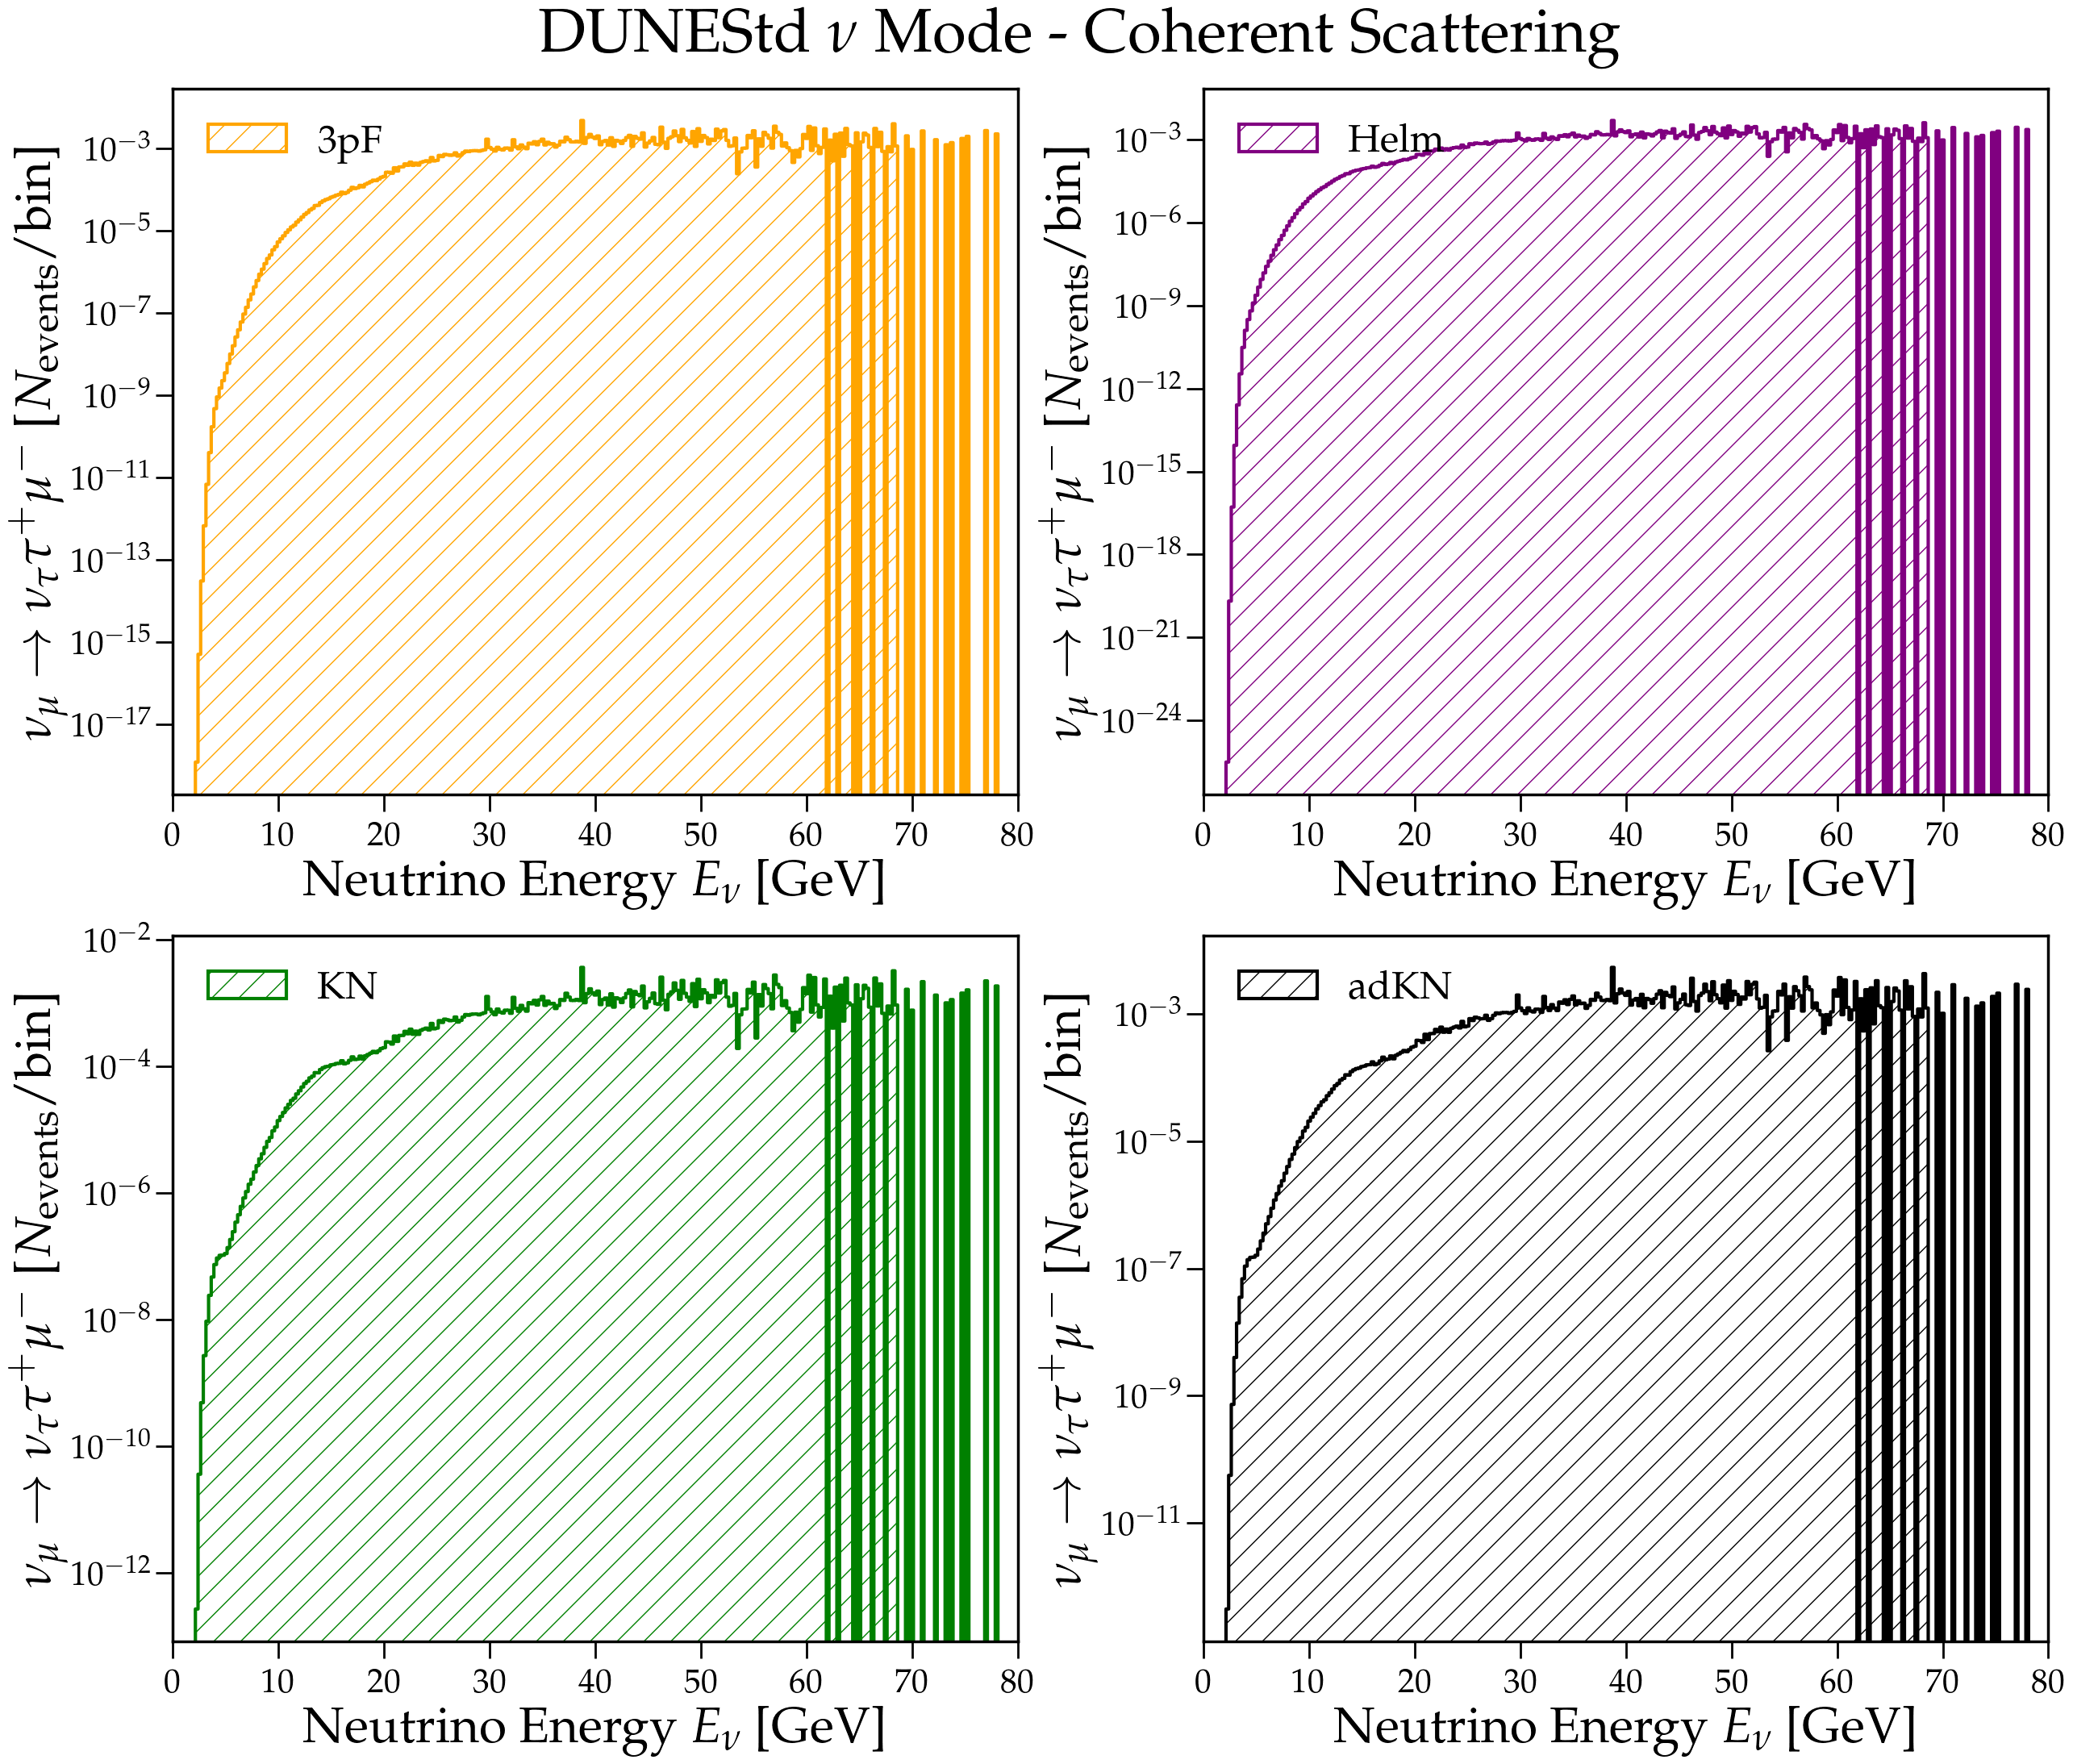

In [27]:
####################################################################################################################
############################### Trident Event Distribution: vmu -> vtau tau+ mu- #######################################
####################################################################################################################
fig = plt.figure(figsize=(30,25))
gs = fig.add_gridspec(2,2,hspace=0.2, wspace=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_3pF = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vtau_tau_mu_coh_Ar_3pF, Xsec_vtau_tau_mu_coh_Ar_3pF, POT=3.3, MD=67)
Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_Helm = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vtau_tau_mu_coh_Ar_Helm, Xsec_vtau_tau_mu_coh_Ar_Helm, POT=3.3, MD=67)
Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_KN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vtau_tau_mu_coh_Ar_KN, Xsec_vtau_tau_mu_coh_Ar_KN, POT=3.3, MD=67)
Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_adKN = ComputeNumberOfEvents(Flux_DUNEStd_NuMode, Enu_DUNEStd_NuMode, Energy_vtau_tau_mu_coh_Ar_adKN, Xsec_vtau_tau_mu_coh_Ar_adKN, POT=3.3, MD=67)

ax1.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_3pF, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax1.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_3pF, step='post', alpha=1, color='none', label='3pF', edgecolor='orange', lw=3, hatch='/')

ax2.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_Helm, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax2.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_Helm, step='post', alpha=1, color='none', label='Helm', edgecolor='purple', lw=3, hatch='/')

ax3.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_KN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax3.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_KN, step='post', alpha=1, color='none', label='KN', edgecolor='green', lw=3, hatch='/')

ax4.bar(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_adKN, width=0.25, align='edge', alpha=1, linewidth=1, edgecolor='none', fill=False)
ax4.fill_between(Enu_DUNEStd_NuMode, Events_DUNEStd_Numode_vtau_tau_mu_coh_Ar_adKN, step='post', alpha=1, color='none', label='adKN', edgecolor='black', lw=3, hatch='/')

for ax, label in zip([ax1, ax2, ax3, ax4],['3pF', 'Helm', 'KN', 'adKN']):
    ax.set_yscale('log')
    ax.set_xlim([0,80])
    ax.tick_params(which='both', right=False, tickdir='out', top=False)
    ax.legend()
    ax.set_ylabel(r'$\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$ [$N_\mathrm{events}/\mathrm{bin}$]')
    ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.gcf().text(0.5,0.905,r'DUNEStd $\nu$ Mode - Coherent Scattering', va='center', ha='center', fontsize=55)

plt.savefig('../Plots/Figures_PDF/DUNEStd_events_per_bin_vtau_tau+_mu-.pdf', bbox_inches='tight', transparent=False)
plt.savefig('../Plots/Figures_PNG/DUNEStd_events_per_bin_vtau_tau+_mu-.png', bbox_inches='tight', transparent=False)

# Event Distribution at DUNE $\tau$-Opt (Neutrino Flux - Neutrino Mode)